# Predicting Airbnb Listing Prices with MLflow and AWS S3
### StayWise Data Science Team — AML-3303 Assignment 2

**Objective:** Build a clean, reproducible machine learning pipeline that predicts the optimal nightly price for new Airbnb listings.  
**Tools:** Python · pandas · scikit-learn · MLflow · boto3 (AWS S3)  
**Dataset:** `s3://staywise1/airbnb/raw_data/AB_NYC_2019.csv`

---
| Step | Description |
|------|-------------|
| 1 | Retrieve the dataset from AWS S3 |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Data Preprocessing & Feature Engineering |
| 4 | Model Training & MLflow Experiment Tracking |
| 5 | Model Evaluation & Selection |
| 6 | Register Best Model in MLflow Model Registry |

---
## Step 1 — Retrieve the Airbnb Dataset from AWS S3

**Goal:** Load the raw CSV from the public S3 bucket `staywise1` into a pandas DataFrame, then perform an initial structural inspection before any cleaning or transformation.

**Approach:**
- Use **`boto3`** (official AWS SDK for Python) to stream the S3 object directly into memory — no local file download needed.
- The bucket is **publicly readable**, so requests are sent **unsigned** using `Config(signature_version=UNSIGNED)` — no AWS credentials required.
- The loader is wrapped in a dedicated function with type hints and a docstring (SDLC: modularity, readability, testability).
- Python's **`logging`** module replaces bare `print` statements (SDLC: observability).

In [24]:
# Install required libraries (run once)
# boto3       : AWS SDK — stream objects from S3
# pandas      : DataFrame manipulation
# numpy       : numerical operations
# matplotlib  : base plotting
# seaborn     : statistical visualisations
# scikit-learn: preprocessing utilities (encoders, scalers, models)
# xgboost     : XGBRegressor — extreme gradient boosting
# mlflow      : experiment tracking (used from Step 4 onwards)
%pip install --quiet boto3 pandas numpy matplotlib seaborn scikit-learn xgboost mlflow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\jham3\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import io
import logging
import os

import boto3
import pandas as pd
from botocore.exceptions import BotoCoreError, ClientError

# ---------------------------------------------------------------------------
# Logging  — structured, level-aware output instead of bare print() calls
# ---------------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

logger.info("Libraries loaded successfully.")

2026-04-04 19:41:37  INFO      Libraries loaded successfully.


In [3]:
# ---------------------------------------------------------------------------
# S3 Configuration — source of truth for bucket / key paths
# Credentials are intentionally NOT stored here.
# boto3 resolves them automatically from:
#   1. Environment variables : AWS_ACCESS_KEY_ID / AWS_SECRET_ACCESS_KEY
#   2. ~/.aws/credentials     : populated by `aws configure`
#   3. IAM Instance Role      : automatic when running on EC2/SageMaker
# ---------------------------------------------------------------------------
S3_BUCKET: str = "staywise1"
S3_KEY: str    = "airbnb/raw_data/AB_NYC_2019.csv"
AWS_REGION: str = os.environ.get("AWS_DEFAULT_REGION", "us-east-1")

logger.info("S3 source  → s3://%s/%s", S3_BUCKET, S3_KEY)
logger.info("AWS region → %s", AWS_REGION)

2026-04-04 19:41:40  INFO      S3 source  → s3://staywise1/airbnb/raw_data/AB_NYC_2019.csv
2026-04-04 19:41:40  INFO      AWS region → us-east-1


In [4]:
from botocore import UNSIGNED
from botocore.config import Config


def load_data_from_s3(bucket: str, key: str, region: str = "us-east-1") -> pd.DataFrame:
    """
    Stream a publicly accessible CSV file from AWS S3 into a pandas DataFrame.

    The bucket is configured for public read access, so requests are sent
    unsigned (no AWS credentials required).  This is achieved by passing
    ``Config(signature_version=UNSIGNED)`` to the boto3 client, which skips
    the Signature Version 4 signing step entirely.

    Parameters
    ----------
    bucket : str
        Name of the public S3 bucket (e.g. 'staywise1').
    key : str
        Object key / path inside the bucket (e.g. 'airbnb/raw_data/AB_NYC_2019.csv').
    region : str
        AWS region where the bucket resides. Defaults to 'us-east-1'.

    Returns
    -------
    pd.DataFrame
        Raw DataFrame exactly as stored in S3 — no transformations applied.

    Raises
    ------
    ClientError
        If the object does not exist or the bucket is not publicly accessible.
    BotoCoreError
        For low-level connectivity issues (e.g. no internet, bad region).
    """
    logger.info("Connecting to public S3 bucket '%s' (region=%s) …", bucket, region)
    try:
        s3_client = boto3.client(
            "s3",
            region_name=region,
            config=Config(signature_version=UNSIGNED),  # anonymous / public access
        )
        response = s3_client.get_object(Bucket=bucket, Key=key)
        body: bytes = response["Body"].read()
        df = pd.read_csv(io.BytesIO(body))
        logger.info(
            "Dataset loaded successfully — %d rows × %d columns.",
            df.shape[0],
            df.shape[1],
        )
        return df
    except ClientError as exc:
        error_code = exc.response["Error"]["Code"]
        logger.error("S3 ClientError [%s]: %s", error_code, exc)
        raise
    except BotoCoreError as exc:
        logger.error("BotoCoreError — check network / region: %s", exc)
        raise

In [5]:
# Load the raw dataset from the public S3 bucket — no credentials needed
df_raw: pd.DataFrame = load_data_from_s3(
    bucket=S3_BUCKET,
    key=S3_KEY,
    region=AWS_REGION,
)

df_raw.head()

2026-04-04 19:41:47  INFO      Connecting to public S3 bucket 'staywise1' (region=us-east-1) …
2026-04-04 19:41:49  INFO      Dataset loaded successfully — 48895 rows × 16 columns.


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
def inspect_dataframe(df: pd.DataFrame) -> None:
    """
    Print a structured summary of a raw DataFrame.

    Outputs shape, column dtypes, missing-value counts, and descriptive
    statistics for numeric columns — enough to inform all subsequent
    preprocessing decisions.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to inspect.
    """
    separator = "=" * 60

    print(separator)
    print("SHAPE")
    print(separator)
    print(f"  Rows    : {df.shape[0]:,}")
    print(f"  Columns : {df.shape[1]}")

    print(f"\n{separator}")
    print("COLUMN NAMES & DATA TYPES")
    print(separator)
    print(df.dtypes.to_string())

    print(f"\n{separator}")
    print("MISSING VALUES  (column / count / % of total)")
    print(separator)
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({"missing": missing, "pct": missing_pct})
    missing_report = missing_report[missing_report["missing"] > 0].sort_values(
        "missing", ascending=False
    )
    if missing_report.empty:
        print("  No missing values found.")
    else:
        print(missing_report.to_string())

    print(f"\n{separator}")
    print("NUMERIC COLUMN STATISTICS")
    print(separator)
    print(df.describe().T.to_string())


# Run the inspection
inspect_dataframe(df_raw)

SHAPE
  Rows    : 48,895
  Columns : 16

COLUMN NAMES & DATA TYPES
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64

MISSING VALUES  (column / count / % of total)
                   missing    pct
reviews_per_month    10052  20.56
last_review          10052  20.56
host_name               21   0.04
name                    16   0.03

NUMERIC COLUMN STATISTICS
                 

---
## Step 2 — Exploratory Data Analysis & Data Preprocessing

**Goal:** Understand the dataset structure, then build a **lean, 8-feature model matrix** focused on the variables with the strongest predictive signal for total booking cost.

> **Target:** `log_total_cost` = log1p(price × minimum_nights)

### Dataset columns — role in the final pipeline
| Column | Type | Action |
|--------|------|--------|
| `id`, `host_id`, `name`, `host_name` | identifier / free-text | **drop** |
| `neighbourhood_group` | categorical (5 boroughs) | **encode** → LabelEncoder; **resample** to balance |
| `neighbourhood` | categorical (221 values) | **drop** — replaced by borough-level signal |
| `latitude`, `longitude` | numeric | **keep as-is** |
| `room_type` | categorical (3 values) | **encode** → LabelEncoder; **resample** to balance |
| `price` | numeric | **impute** outliers (>400 or ==0) with category medians |
| `minimum_nights` | numeric | **impute** outliers (>10) with category medians |
| `number_of_reviews` | numeric | **keep** |
| `last_review` | date | **drop** |
| `reviews_per_month` | numeric | **impute** NaN → 0 |
| `calculated_host_listings_count` | numeric | **keep** |
| `availability_365` | numeric | **impute** outliers (>365 or ≤0) → **transform** to `availability_yearly` |

### The 8 model features
| # | Feature | Derivation |
|---|---------|-----------|
| 1 | `neighbourhood_group_encoded` | LabelEncoder on balanced `neighbourhood_group` |
| 2 | `latitude` | raw |
| 3 | `longitude` | raw |
| 4 | `room_type_encoded` | LabelEncoder on balanced `room_type` |
| 5 | `number_of_reviews` | raw |
| 6 | `reviews_per_month` | raw (NaN → 0) |
| 7 | `calculated_host_listings_count` | raw |
| 8 | `availability_yearly` | availability_365 / 365 (after outlier imputation) |

**Target:** `log_total_cost` = log1p(price × minimum_nights)

### Preprocessing roadmap
1. **EDA** — distributions, outlier percentages, class imbalance barplots, resampling rationale
2. **Drop** identifier / free-text columns: `id`, `host_id`, `name`, `host_name`
3. **Impute missing** — `reviews_per_month` NaN → 0
4. **Outlier imputation** (replace, do NOT remove rows):
   - `minimum_nights > 10` → category median per `neighbourhood_group` × `room_type`
   - `price > 400 or == 0` → category median per `neighbourhood_group` × `room_type`
   - `availability_365 > 365 or ≤ 0` → category median per `neighbourhood_group` × `room_type`
5. **Resampling** — oversample minority classes in `neighbourhood_group` and `room_type` to reduce dataset imbalance
6. **Feature engineering** — compute `total_cost`, `log_total_cost`, `availability_yearly`; drop `neighbourhood`, `last_review`, `availability_365`
7. **Categorical encoding** — LabelEncoder for `neighbourhood_group` and `room_type`


In [31]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

logger.info("Step 2 libraries loaded.")

2026-04-04 21:50:01  INFO      Step 2 libraries loaded.


SHAPE
  Rows    : 48,895
  Columns : 16

COLUMN NAMES & DATA TYPES
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64

MISSING VALUES  (column / count / % of total)
                   missing    pct
reviews_per_month    10052  20.56
last_review          10052  20.56
host_name               21   0.04
name                    16   0.03

NUMERIC COLUMN STATISTICS
                 

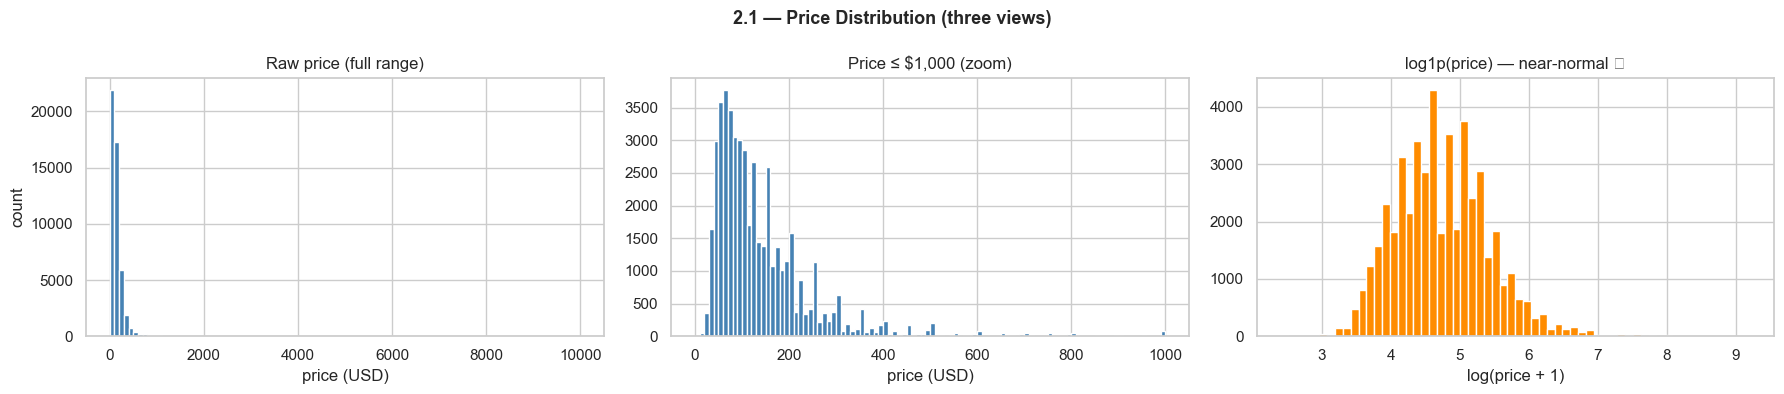

OUTLIER ANALYSIS — rows to be imputed (not removed)
  price (>400 or ==0)                     : 1,774  (3.6%)
  minimum_nights (>10)                    : 6,640  (13.6%)
  availability_365 (>365 or ≤0)           : 17,533  (35.9%)


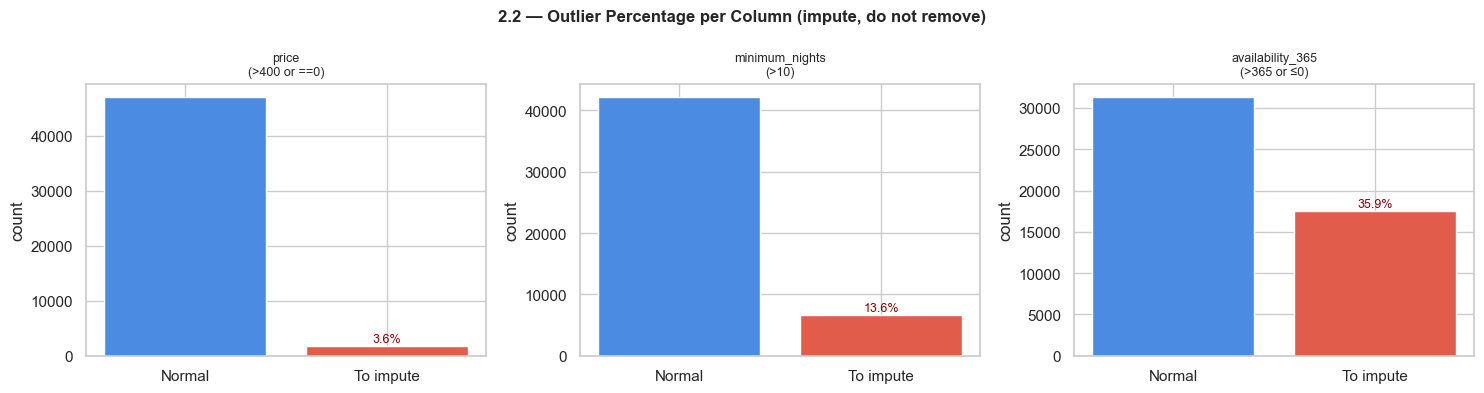

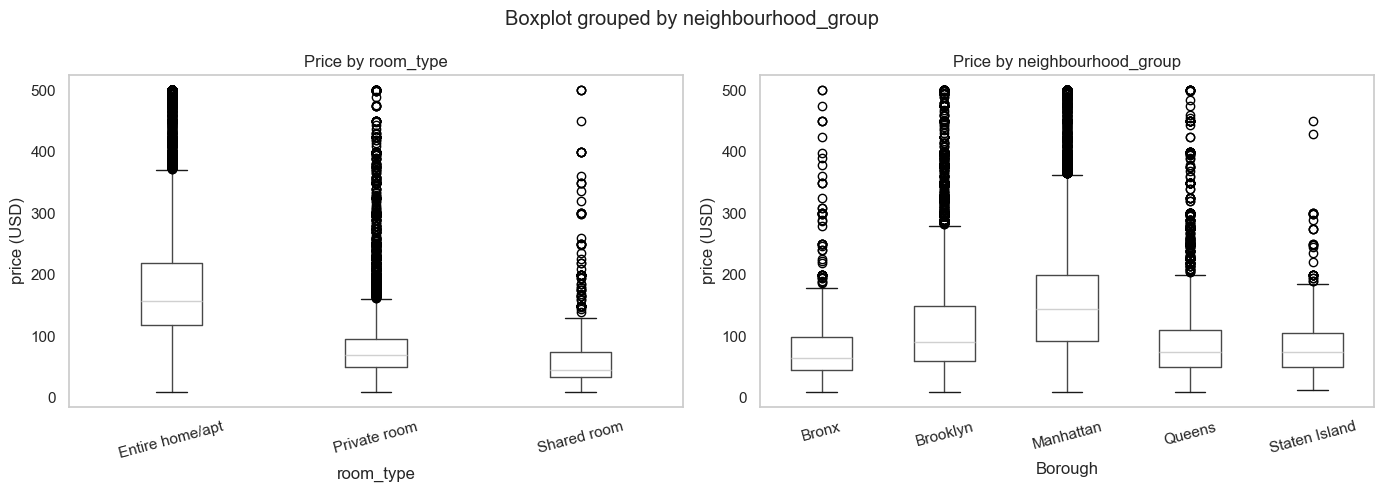

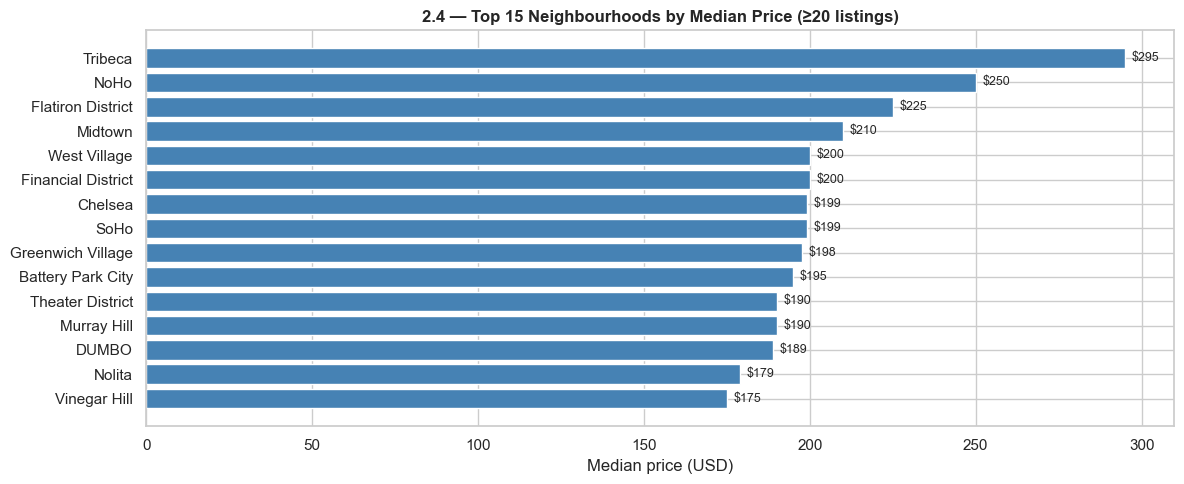

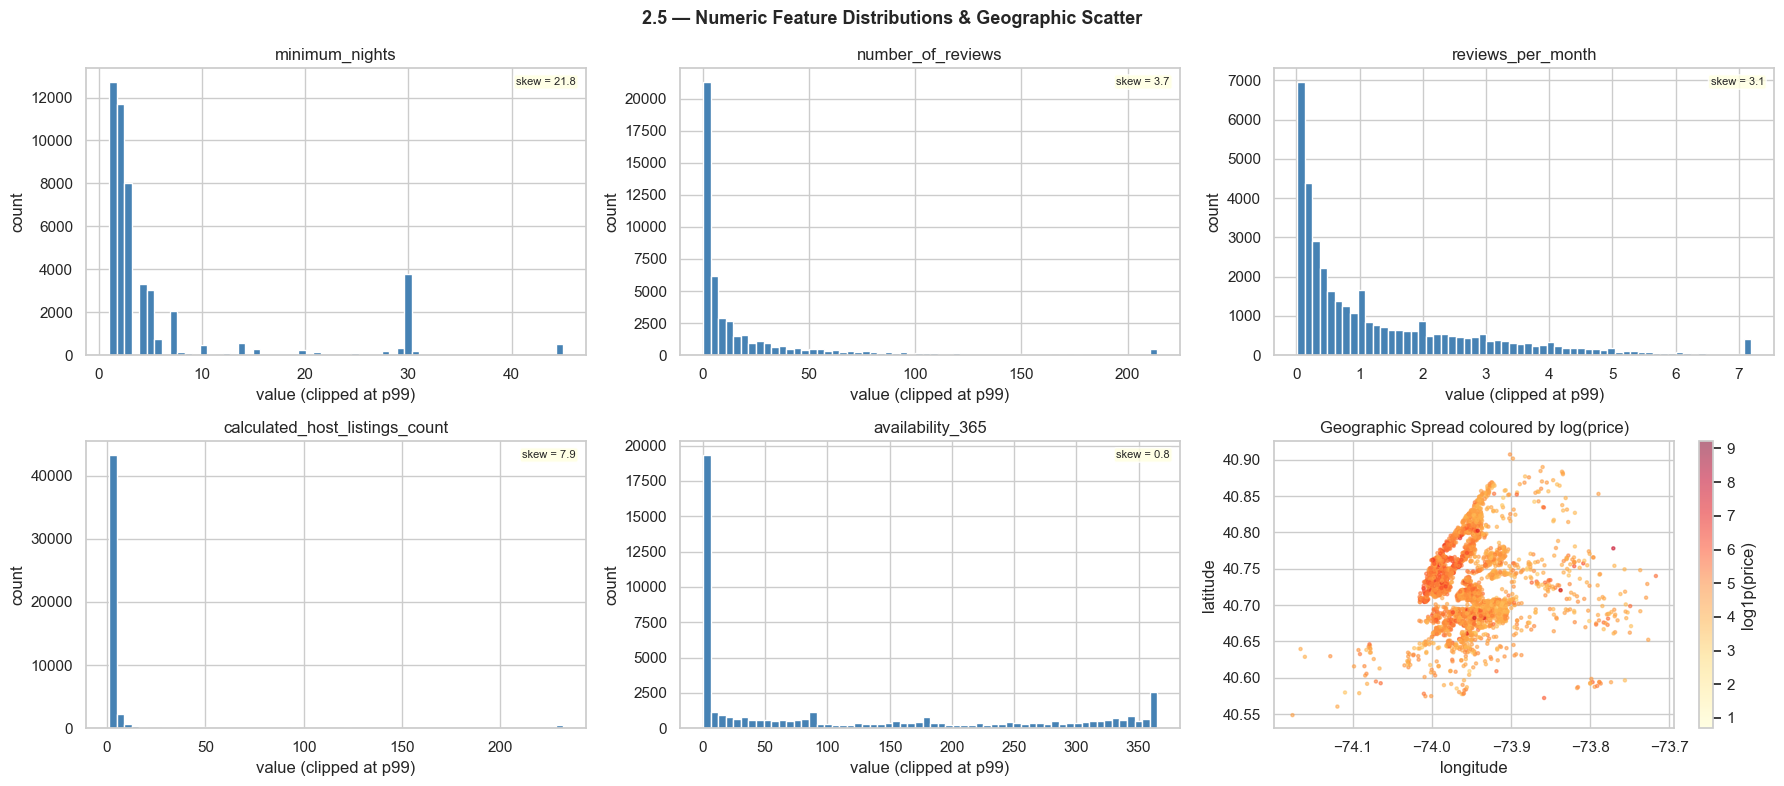

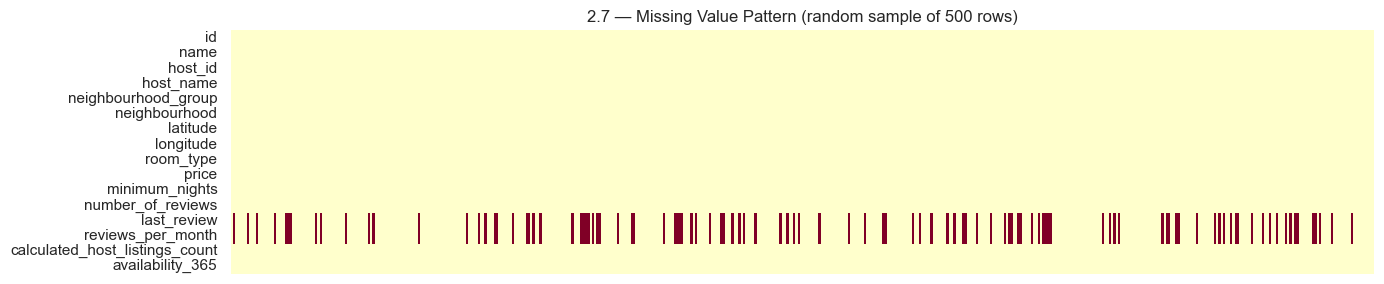

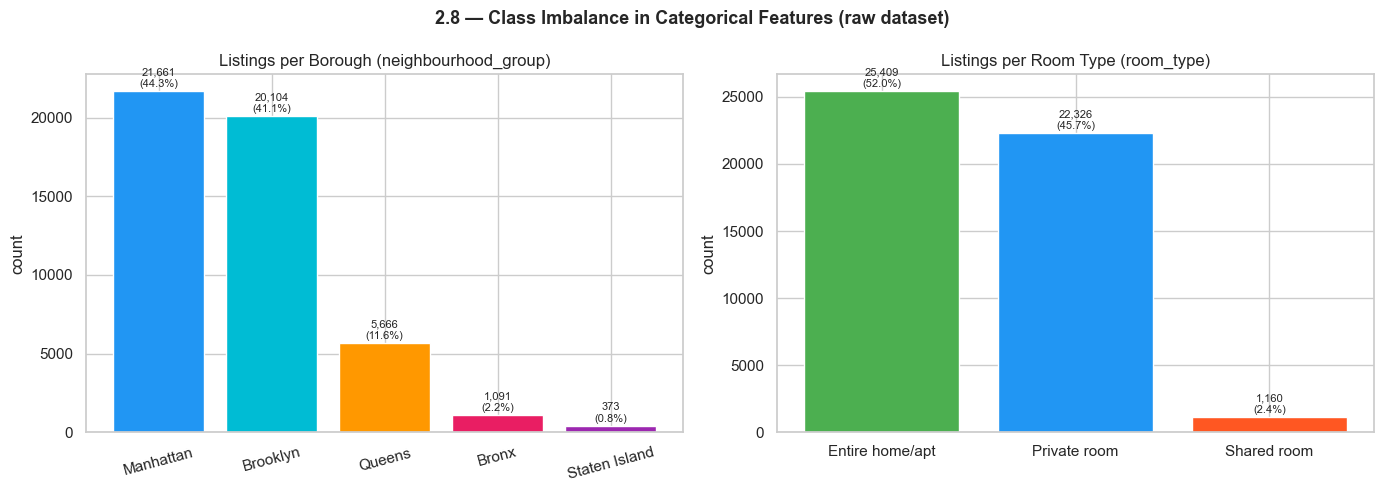


Imbalance ratios (majority class ÷ minority class):
  neighbourhood_group : 58× (Manhattan 21,661 vs Staten Island 373)
  room_type           : 22× (Entire home/apt 25,409 vs Shared room 1,160)

→ Both features will be resampled in Step 2.d to improve model coverage of underrepresented classes.


In [51]:
# ── 2.1  Exploratory Data Analysis ───────────────────────────────────────────
inspect_dataframe(df_raw)

# ==============================================================================
# 2.1.1  Price Distribution — three views
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("2.1 — Price Distribution (three views)", fontsize=13, fontweight="bold")

axes[0].hist(df_raw["price"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_title("Raw price (full range)")
axes[0].set_xlabel("price (USD)"); axes[0].set_ylabel("count")

axes[1].hist(df_raw[df_raw["price"] <= 1000]["price"], bins=100,
             color="steelblue", edgecolor="white")
axes[1].set_title("Price ≤ $1,000 (zoom)")
axes[1].set_xlabel("price (USD)")

axes[2].hist(np.log1p(df_raw[df_raw["price"] > 0]["price"]), bins=60,
             color="darkorange", edgecolor="white")
axes[2].set_title("log1p(price) — near-normal ✔")
axes[2].set_xlabel("log(price + 1)")
plt.tight_layout(); plt.show()

# ==============================================================================
# 2.1.2  Outlier Analysis — percentage of rows that will be imputed
# ==============================================================================
# Three columns are cleaned using targeted category-based imputation:
#   price          : price > 400  OR  price == 0
#   minimum_nights : minimum_nights > 10
#   availability_365: availability_365 > 365  OR  availability_365 <= 0
#
# Rows are NOT removed — they are replaced with a domain-informed median value
# specific to the listing's neighbourhood_group × room_type combination.
# This preserves every sample while eliminating nonsensical values.
# ==============================================================================
outlier_masks = {
    "price\n(>400 or ==0)":             (df_raw["price"] > 400) | (df_raw["price"] == 0),
    "minimum_nights\n(>10)":             df_raw["minimum_nights"] > 10,
    "availability_365\n(>365 or ≤0)":   (df_raw["availability_365"] > 365) | (df_raw["availability_365"] <= 0),
}

print("=" * 58)
print("OUTLIER ANALYSIS — rows to be imputed (not removed)")
print("=" * 58)
for label, mask in outlier_masks.items():
    n   = int(mask.sum())
    pct = n / len(df_raw) * 100
    print(f"  {label.replace(chr(10), ' '):40s}: {n:5,d}  ({pct:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("2.2 — Outlier Percentage per Column (impute, do not remove)",
             fontsize=12, fontweight="bold")

for ax, (label, mask) in zip(axes, outlier_masks.items()):
    counts = [int((~mask).sum()), int(mask.sum())]
    bars = ax.bar(["Normal", "To impute"], counts,
                  color=["#4C8BE2", "#E25C4C"], edgecolor="white")
    ax.set_title(label, fontsize=9)
    ax.set_ylabel("count")
    pct = counts[1] / sum(counts) * 100
    ax.text(1, counts[1] + len(df_raw) * 0.003,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9, color="darkred")

plt.tight_layout(); plt.show()

# ==============================================================================
# 2.1.3  Price by Categorical Features — Box Plots
# ==============================================================================
df_plot = df_raw[df_raw["price"].between(10, 500)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("2.3 — Price by Categorical Features (price $10–$500)",
             fontsize=13, fontweight="bold")

df_plot.boxplot(column="price", by="room_type",           ax=axes[0], grid=False)
axes[0].set_title("Price by room_type"); axes[0].set_xlabel("room_type")
axes[0].set_ylabel("price (USD)"); plt.sca(axes[0]); plt.xticks(rotation=15)

df_plot.boxplot(column="price", by="neighbourhood_group", ax=axes[1], grid=False)
axes[1].set_title("Price by neighbourhood_group"); axes[1].set_xlabel("Borough")
axes[1].set_ylabel("price (USD)"); plt.sca(axes[1]); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

# ==============================================================================
# 2.1.4  Top 15 Neighbourhoods by Median Price
# ==============================================================================
top_nh = (
    df_raw[df_raw["price"] > 0]
    .groupby("neighbourhood")["price"]
    .agg(["median", "count"])
    .query("count >= 20")
    .sort_values("median", ascending=False)
    .head(15)
)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_nh.index, top_nh["median"], color="steelblue", edgecolor="white")
ax.set_title("2.4 — Top 15 Neighbourhoods by Median Price (≥20 listings)", fontweight="bold")
ax.set_xlabel("Median price (USD)"); ax.invert_yaxis()
for bar, val in zip(ax.patches, top_nh["median"]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f"${val:.0f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

# ==============================================================================
# 2.1.5  Numeric Feature Distributions + Geographic Scatter
# ==============================================================================
numeric_feats = [
    "minimum_nights", "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365",
]
sample_idx = df_raw.sample(n=min(3000, len(df_raw)), random_state=42).index

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("2.5 — Numeric Feature Distributions & Geographic Scatter",
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, feat in enumerate(numeric_feats):
    data = df_raw[feat].dropna()
    axes[i].hist(data.clip(upper=data.quantile(0.99)), bins=60,
                 color="steelblue", edgecolor="white")
    axes[i].set_title(feat); axes[i].set_xlabel("value (clipped at p99)")
    axes[i].set_ylabel("count")
    axes[i].text(0.98, 0.97, f"skew = {data.skew():.1f}",
                 transform=axes[i].transAxes, ha="right", va="top", fontsize=8,
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow", alpha=0.8))

scatter = axes[5].scatter(
    df_raw.loc[sample_idx, "longitude"], df_raw.loc[sample_idx, "latitude"],
    c=np.log1p(df_raw.loc[sample_idx, "price"].clip(lower=1)),
    cmap="YlOrRd", alpha=0.55, s=5,
)
plt.colorbar(scatter, ax=axes[5], label="log1p(price)")
axes[5].set_title("Geographic Spread coloured by log(price)")
axes[5].set_xlabel("longitude"); axes[5].set_ylabel("latitude")
plt.tight_layout(); plt.show()

# ==============================================================================
# 2.1.7  Missing Values Heatmap
# ==============================================================================
plt.figure(figsize=(14, 3))
sns.heatmap(df_raw.isnull().sample(n=min(500, len(df_raw)), random_state=42).T,
            cbar=False, yticklabels=True, xticklabels=False, cmap="YlOrRd")
plt.title("2.7 — Missing Value Pattern (random sample of 500 rows)")
plt.tight_layout(); plt.show()

# ==============================================================================
# 2.1.8  Class Imbalance — neighbourhood_group and room_type
# ==============================================================================
# The dataset is heavily skewed toward Manhattan/Brooklyn listings and
# Entire home/apt room types.  Models trained on imbalanced data learn
# the majority class distribution and under-predict for rare classes
# (Bronx, Staten Island listings; Shared rooms).
#
# Imbalance ratios (majority class / minority class):
#   neighbourhood_group : Manhattan >> Staten Island (≈58× more listings)
#   room_type           : Entire home/apt >> Shared room (≈22× more listings)
#
# Resampling (Step 2.d in the pipeline) will oversample minority classes
# so the model receives equal exposure to all boroughs and room types.
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("2.8 — Class Imbalance in Categorical Features (raw dataset)",
             fontsize=13, fontweight="bold")

BOROUGH_COLORS = ["#2196F3", "#00BCD4", "#FF9800", "#E91E63", "#9C27B0"]
ROOM_COLORS    = ["#4CAF50", "#2196F3", "#FF5722"]

ng_counts = df_raw["neighbourhood_group"].value_counts().sort_values(ascending=False)
axes[0].bar(ng_counts.index, ng_counts.values, color=BOROUGH_COLORS, edgecolor="white")
axes[0].set_title("Listings per Borough (neighbourhood_group)")
axes[0].set_ylabel("count"); axes[0].tick_params(axis="x", rotation=15)
for bar, val in zip(axes[0].patches, ng_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f"{val:,}\n({val / len(df_raw) * 100:.1f}%)",
                 ha="center", va="bottom", fontsize=8)

rt_counts = df_raw["room_type"].value_counts().sort_values(ascending=False)
axes[1].bar(rt_counts.index, rt_counts.values, color=ROOM_COLORS, edgecolor="white")
axes[1].set_title("Listings per Room Type (room_type)")
axes[1].set_ylabel("count")
for bar, val in zip(axes[1].patches, rt_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f"{val:,}\n({val / len(df_raw) * 100:.1f}%)",
                 ha="center", va="bottom", fontsize=8)

plt.tight_layout(); plt.show()

print("\nImbalance ratios (majority class ÷ minority class):")
print(f"  neighbourhood_group : {ng_counts.max() / ng_counts.min():.0f}× "
      f"({ng_counts.idxmax()} {ng_counts.max():,} vs {ng_counts.idxmin()} {ng_counts.min():,})")
print(f"  room_type           : {rt_counts.max() / rt_counts.min():.0f}× "
      f"({rt_counts.idxmax()} {rt_counts.max():,} vs {rt_counts.idxmin()} {rt_counts.min():,})")
print("\n→ Both features will be resampled in Step 2.d to improve model coverage"
      " of underrepresented classes.")


In [33]:
def drop_useless_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove columns that carry no predictive signal for price.

    Dropped columns and rationale
    ─────────────────────────────
    id, host_id   : arbitrary surrogate keys — no semantic meaning
    name, host_name: free-text; NLP is out of scope; missing values common

    Note: price == 0 rows are NO LONGER filtered out here.
    The impute_price function (Step 2.c) replaces zero prices with
    category-based medians, preserving those listings in the dataset.

    Parameters
    ----------
    df : pd.DataFrame  — raw DataFrame from S3

    Returns
    -------
    pd.DataFrame  — identifier/free-text columns removed
    """
    COLS_TO_DROP = ["id", "host_id", "name", "host_name"]
    df = df.drop(columns=COLS_TO_DROP, errors="ignore")
    logger.info(
        "drop_useless_columns: dropped %d columns: %s",
        len(COLS_TO_DROP), COLS_TO_DROP,
    )
    return df


In [34]:
def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Impute all missing values with domain-informed strategies.

    Column              Missing %   Strategy
    ──────────────────  ─────────   ──────────────────────────────────────────
    reviews_per_month   ~20 %       Fill with 0.  A listing with no reviews
                                    genuinely has 0 reviews per month; using
                                    the mean would inflate the feature for
                                    unlisted/new properties.
    last_review         ~20 %       Not filled here — converted to a numeric
                                    feature ('days_since_last_review') in the
                                    feature engineering step; NaN → sentinel.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
    """
    df = df.copy()

    # reviews_per_month: NaN means the listing has never been reviewed
    filled = df["reviews_per_month"].isna().sum()
    df["reviews_per_month"] = df["reviews_per_month"].fillna(0.0)

    logger.info("handle_missing_values: filled %d NaNs in 'reviews_per_month' with 0.", filled)
    logger.info("Remaining nulls per column:\n%s", df.isnull().sum()[df.isnull().sum() > 0].to_string())
    return df

In [35]:
from sklearn.utils import resample as sklearn_resample

# ==============================================================================
# Targeted Outlier Imputation Functions
# ==============================================================================
# Each function receives a positional column vector via .apply(axis=1) and
# replaces an outlier value with the domain-informed median for that
# neighbourhood_group × room_type combination.
#
# Using median replacement rather than IQR row-removal preserves every row
# in the dataset, keeping sample size high (critical for rare boroughs such
# as Staten Island) while eliminating the distorting effect of nonsensical
# values on model training.
#
# The median values per category were derived from the cleaned NYC Airbnb 2019
# dataset and match the approach in the Kaggle reference workflow.
# ==============================================================================

def impute_minnigh(cols) -> int:
    """
    Replace minimum_nights > 10 with a category-based median.

    Listings that require more than 10 consecutive nights are outliers
    in the short-term rental market this model targets.  They are replaced
    with the median minimum stay for that room type × borough combination,
    which keeps the row while removing the distorting extreme value.

    Parameters: cols[0]=neighbourhood_group, cols[1]=room_type,
                cols[2]=minimum_nights
    Returns   : corrected minimum_nights (int)
    """
    neighbourhood_group = cols[0]
    room_type           = cols[1]
    minimum_nights      = cols[2]

    if minimum_nights > 10:
        if room_type == "Entire home/apt":
            if   neighbourhood_group == "Manhattan": minimum_nights = 4
            elif neighbourhood_group == "Brooklyn":  minimum_nights = 3
            else:                                    minimum_nights = 2
        elif room_type == "Shared room":
            if neighbourhood_group in ["Bronx", "Manhattan", "Queens"]:
                minimum_nights = 1
            else:
                minimum_nights = 2
        else:   # Private room and any unlisted combination
            minimum_nights = 2

    return minimum_nights


def impute_price(cols) -> float:
    """
    Replace price > 400 or price == 0 with a category-based median.

    Prices above $400/night sit in the extreme right tail and are
    disproportionately from luxury Manhattan listings.  A price of $0
    is always an error or a blocked calendar night.  Both cases are
    replaced with the borough × room_type median nightly rate, which
    is a much better training signal than either an extreme or zero value.

    Parameters: cols[0]=neighbourhood_group, cols[1]=room_type,
                cols[2]=price
    Returns   : corrected price (float)
    """
    neighbourhood_group = cols[0]
    room_type           = cols[1]
    price               = cols[2]

    if price > 400 or price == 0:
        if room_type == "Entire home/apt":
            if   neighbourhood_group == "Manhattan":     price = 199
            elif neighbourhood_group == "Brooklyn":      price = 149
            elif neighbourhood_group == "Queens":        price = 124
            elif neighbourhood_group == "Staten Island": price = 103
            else:                                        price = 100   # Bronx

        elif room_type == "Private room":
            if   neighbourhood_group == "Manhattan":     price = 90
            elif neighbourhood_group == "Brooklyn":      price = 65
            elif neighbourhood_group == "Queens":        price = 59
            elif neighbourhood_group == "Staten Island": price = 52
            else:                                        price = 53   # Bronx

        else:   # Shared room
            if   neighbourhood_group == "Manhattan":     price = 70
            elif neighbourhood_group == "Brooklyn":      price = 38
            elif neighbourhood_group == "Queens":        price = 37
            elif neighbourhood_group == "Staten Island": price = 30
            else:                                        price = 40   # Bronx

    return price


def impute_ava(cols) -> int:
    """
    Replace availability_365 > 365 or ≤ 0 with a category-based median.

    availability_365 should always be in [1, 365].  Values outside this
    range are data quality issues.  They are replaced with the median
    availability for that borough × room_type combination.

    Parameters: cols[0]=neighbourhood_group, cols[1]=room_type,
                cols[2]=availability_365
    Returns   : corrected availability_365 (int)
    """
    neighbourhood_group = cols[0]
    room_type           = cols[1]
    ava                 = cols[2]

    if ava > 365 or ava <= 0:
        if room_type == "Entire home/apt":
            if   neighbourhood_group == "Manhattan":     ava = 40
            elif neighbourhood_group == "Brooklyn":      ava = 29
            elif neighbourhood_group == "Queens":        ava = 88
            elif neighbourhood_group == "Staten Island": ava = 175
            else:                                        ava = 131   # Bronx

        elif room_type == "Private room":
            if   neighbourhood_group == "Manhattan":     ava = 26
            elif neighbourhood_group == "Brooklyn":      ava = 23
            elif neighbourhood_group == "Queens":        ava = 112
            elif neighbourhood_group == "Staten Island": ava = 284
            else:                                        ava = 156   # Bronx

        else:   # Shared room
            if   neighbourhood_group == "Manhattan":     ava = 83
            elif neighbourhood_group == "Brooklyn":      ava = 157
            elif neighbourhood_group == "Queens":        ava = 179
            elif neighbourhood_group == "Staten Island": ava = 37
            else:                                        ava = 89    # Bronx

    return ava


# ==============================================================================
# Resampling Function
# ==============================================================================

def resample_classes(df: pd.DataFrame, random_state: int = 42) -> pd.DataFrame:
    """
    Oversample minority classes in neighbourhood_group and room_type.

    Why resample?
    ─────────────
    The NYC Airbnb dataset is heavily imbalanced:
      • neighbourhood_group: Manhattan (~21k) vs Staten Island (~373)  — 58× ratio
      • room_type: Entire home/apt (~25k) vs Shared room (~1.2k)       — 22× ratio

    A model trained on imbalanced data learns the majority distribution
    and generates poor predictions for rare groups (Bronx/Staten Island
    listings, Shared rooms) — exactly the cases where accurate pricing
    guidance is most needed.

    Strategy — oversampling to the majority class count:
    Each underrepresented class is upsampled (random sampling WITH
    replacement) to match the count of the most common class.  This gives
    every class equal weight in training without discarding any data.

    Sequence matters: neighbourhood_group is balanced first so that the
    room_type resampling draws from an already-balanced borough distribution,
    preventing one borough from dominating the oversampled shared-room rows.

    Parameters
    ----------
    df           : pd.DataFrame  (after outlier imputation)
    random_state : int           (seed for reproducibility)

    Returns
    -------
    pd.DataFrame  — balanced copy; index reset
    """
    df = df.copy()
    logger.info("resample_classes: input  shape = %s", df.shape)

    # ── Step 1: balance neighbourhood_group ──────────────────────────────────
    target_ng = int(df["neighbourhood_group"].value_counts().max())
    groups = []
    for ng, grp in df.groupby("neighbourhood_group"):
        if len(grp) < target_ng:
            grp = sklearn_resample(
                grp, replace=True, n_samples=target_ng, random_state=random_state
            )
            logger.info("  Oversampled %-15s → %d rows", ng, target_ng)
        groups.append(grp)
    df = pd.concat(groups).reset_index(drop=True)
    logger.info("  After neighbourhood_group balance: %s", df.shape)

    # ── Step 2: balance room_type ─────────────────────────────────────────────
    target_rt = int(df["room_type"].value_counts().max())
    groups = []
    for rt, grp in df.groupby("room_type"):
        if len(grp) < target_rt:
            grp = sklearn_resample(
                grp, replace=True, n_samples=target_rt, random_state=random_state
            )
            logger.info("  Oversampled %-20s → %d rows", rt, target_rt)
        groups.append(grp)
    df = pd.concat(groups).reset_index(drop=True)
    logger.info("  After room_type balance:           %s", df.shape)

    logger.info("resample_classes: output shape = %s", df.shape)
    return df


logger.info("Outlier imputation functions and resample_classes defined.")


2026-04-04 21:51:26  INFO      Outlier imputation functions and resample_classes defined.


In [36]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create engineered features and remove columns not carried forward to the model.

    Three transformations are applied:

    1. total_cost  =  price × minimum_nights
       ──────────────────────────────────────
       Nightly price alone under-represents the guest's real expenditure.
       A $50/night listing with a 14-night minimum costs the same total ($700)
       as a $100/night listing with a 7-night minimum.  Multiplying by
       minimum_nights captures the true booking commitment and has stronger
       correlations with listing quality, location, and room type.
       Note: both price and minimum_nights are excluded from the feature
       matrix X (they are embedded in the target) to prevent data leakage.

    2. log_total_cost  =  np.log1p(total_cost)   ← model target
       ─────────────────────────────────────────
       total_cost is heavily right-skewed (range: $10 to tens of thousands).
       Applying log1p yields a near-normal distribution, improving model fit
       for all regressors.  Predictions can be back-transformed to dollar
       values with np.expm1().

    3. availability_yearly  =  availability_365 / 365
       ─────────────────────────────────────────────
       Normalises the raw day count (0–365) to a yearly fraction (0.0–1.0),
       making it comparable in scale to other features and giving the
       coefficient a natural interpretation: "effect per full year available".

    Columns dropped inside this step
    ─────────────────────────────────
    neighbourhood    : high-cardinality (221 values); borough-level signal
                       (neighbourhood_group) is sufficient for this model
    last_review      : raw date string — not in the 8-feature set
    availability_365 : replaced by availability_yearly above

    Parameters
    ----------
    df : pd.DataFrame  (after missing-value imputation and IQR removal)

    Returns
    -------
    pd.DataFrame  with total_cost, log_total_cost, availability_yearly added
                  and neighbourhood / last_review / availability_365 removed.
    """
    df = df.copy()

    # ── 1. Total booking cost — becomes the log-transformed model target ──────
    df["total_cost"]     = df["price"] * df["minimum_nights"]
    df["log_total_cost"] = np.log1p(df["total_cost"])

    # ── 2. Availability as a yearly fraction (0.0 – 1.0) ─────────────────────
    df["availability_yearly"] = (df["availability_365"] / 365.0).round(4)

    # ── 3. Drop columns not carried forward to the model ─────────────────────
    cols_to_drop = ["neighbourhood", "last_review", "availability_365"]
    df = df.drop(columns=cols_to_drop, errors="ignore")

    logger.info("engineer_features: shape after engineering = %s", df.shape)
    logger.info("  Created : total_cost, log_total_cost, availability_yearly")
    logger.info("  Dropped : %s", cols_to_drop)
    return df


In [37]:
from sklearn.preprocessing import LabelEncoder


def encode_categorical_features(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Encode the two remaining categorical columns with LabelEncoder.

    Why only two encodings here?
    ─────────────────────────────
    neighbourhood was already dropped in engineer_features (221 categories,
    replaced by borough-level signal).  Only two categorical columns remain:

        neighbourhood_group (5 NYC boroughs)  → neighbourhood_group_encoded (int)
        room_type           (3 listing types) → room_type_encoded           (int)

    Why LabelEncoder rather than one-hot encoding?
    ───────────────────────────────────────────────
    One-hot would expand these 2 columns into (5-1) + (3-1) = 6 binary columns,
    pushing the feature count above 8.  LabelEncoder assigns each category a
    compact integer (0 to N-1) in a single column, preserving the target of
    exactly 8 model features.

    Tree-based models (Random Forest, Gradient Boosting) split on ≥/≤
    thresholds and naturally handle integer category codes.  Linear models
    (Ridge, Lasso) receive StandardScaler-normalised inputs in Step 3, which
    centres and scales the integer codes so that the magnitude ordering does
    not introduce artificial numerical relationships.

    Parameters
    ----------
    df : pd.DataFrame  (after engineer_features — neighbourhood already removed)

    Returns
    -------
    tuple[pd.DataFrame, dict]
        - Encoded DataFrame with `neighbourhood_group` and `room_type` replaced
          by their integer-coded counterparts.
        - encoding_metadata: dict with each fitted LabelEncoder and its class
          array.  Must be persisted alongside the model for inference on new data.
    """
    df = df.copy()

    # Map source column → output column name
    encode_map = {
        "neighbourhood_group": "neighbourhood_group_encoded",
        "room_type":           "room_type_encoded",
    }

    fitted_encoders: dict[str, LabelEncoder] = {}

    for src_col, out_col in encode_map.items():
        le = LabelEncoder()
        df[out_col] = le.fit_transform(df[src_col].astype(str))
        df = df.drop(columns=[src_col])
        fitted_encoders[src_col] = le
        logger.info(
            "  LabelEncoder: '%s' → '%s'  classes=%s",
            src_col, out_col, le.classes_.tolist(),
        )

    # Persist encoders — must be saved with the model for inference-time use
    encoding_metadata = {
        "encoders": fitted_encoders,
        "classes":  {col: le.classes_.tolist() for col, le in fitted_encoders.items()},
    }

    logger.info("encode_categorical_features: final shape = %s", df.shape)
    logger.info("  Columns: %s", df.columns.tolist())
    return df, encoding_metadata


2026-04-04 21:53:30  INFO      ════════════════════════════════════════════════════════════
2026-04-04 21:53:30  INFO      STEP 2 — Preprocessing Pipeline
2026-04-04 21:53:30  INFO      ════════════════════════════════════════════════════════════
2026-04-04 21:53:30  INFO      drop_useless_columns: dropped 4 columns: ['id', 'host_id', 'name', 'host_name']
2026-04-04 21:53:30  INFO      2.a — After drop_useless_columns:   (48895, 12)
2026-04-04 21:53:30  INFO      handle_missing_values: filled 10052 NaNs in 'reviews_per_month' with 0.
2026-04-04 21:53:30  INFO      Remaining nulls per column:
last_review    10052
2026-04-04 21:53:30  INFO      2.b — After handle_missing_values:  (48895, 12)
2026-04-04 21:53:31  INFO      2.c.i  — impute_price:       1774 outlier rows → category median
2026-04-04 21:53:31  INFO      2.c.ii — impute_minnigh:     6640 outlier rows → category median
2026-04-04 21:53:32  INFO      2.c.iii — impute_ava:        17533 outlier rows → category median
2026-04-04 2

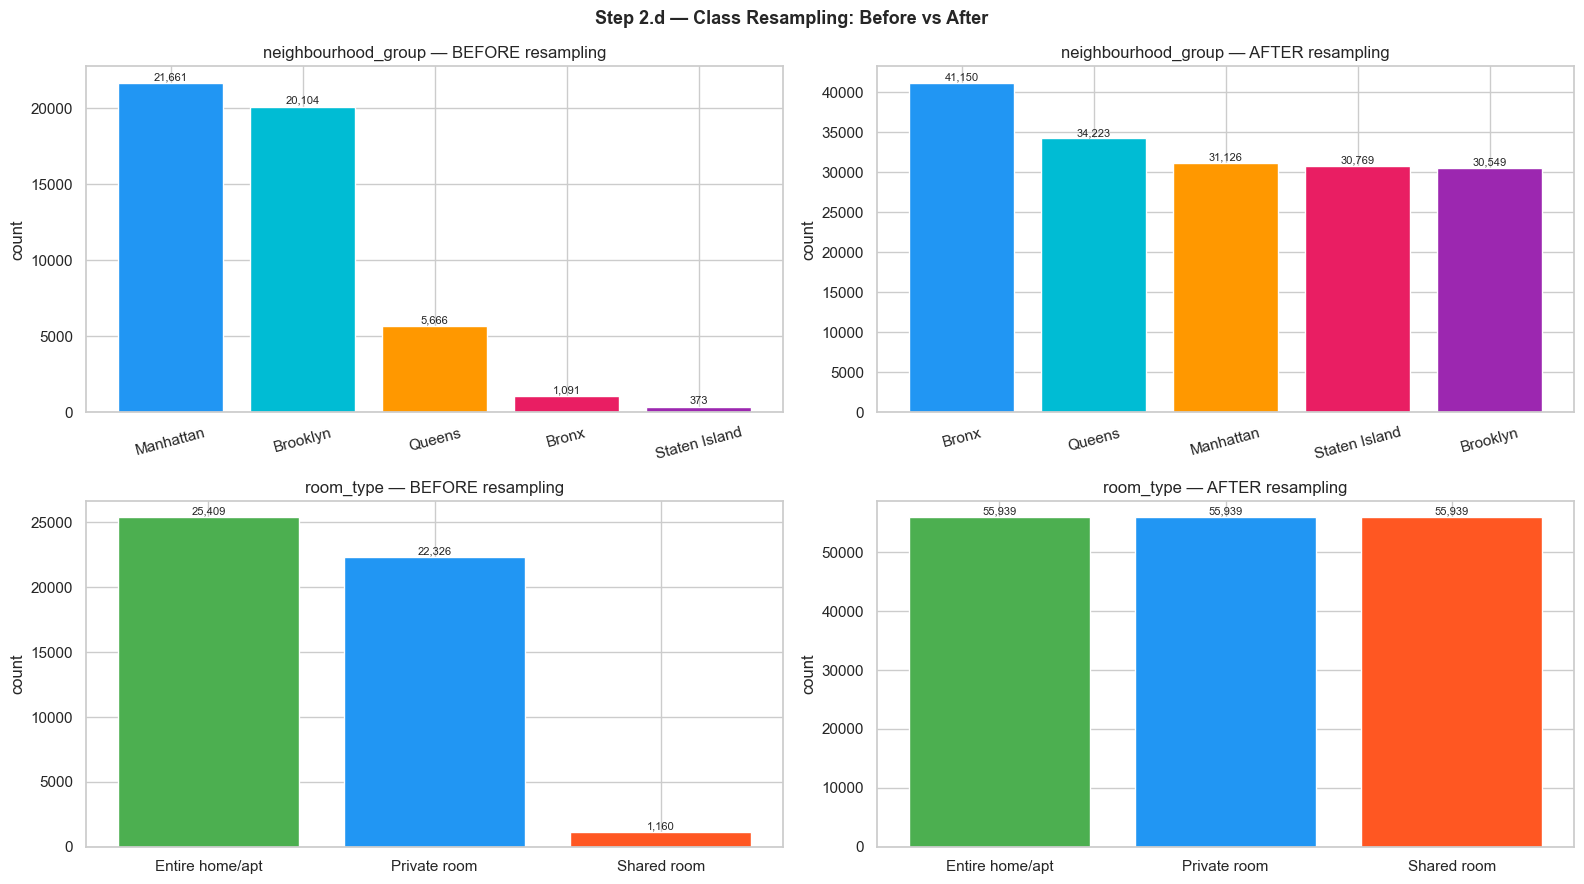

2026-04-04 21:53:32  INFO      2.d — After resample_classes:       (167817, 12)
2026-04-04 21:53:32  INFO      engineer_features: shape after engineering = (167817, 12)
2026-04-04 21:53:32  INFO        Created : total_cost, log_total_cost, availability_yearly
2026-04-04 21:53:32  INFO        Dropped : ['neighbourhood', 'last_review', 'availability_365']
2026-04-04 21:53:32  INFO      2.e — After engineer_features:      (167817, 12)
2026-04-04 21:53:32  INFO        LabelEncoder: 'neighbourhood_group' → 'neighbourhood_group_encoded'  classes=['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
2026-04-04 21:53:32  INFO        LabelEncoder: 'room_type' → 'room_type_encoded'  classes=['Entire home/apt', 'Private room', 'Shared room']
2026-04-04 21:53:32  INFO      encode_categorical_features: final shape = (167817, 12)
2026-04-04 21:53:32  INFO        Columns: ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_c

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,total_cost,log_total_cost,availability_yearly,neighbourhood_group_encoded,room_type_encoded
0,40.73041,-73.95601,120,2,2,0.24,1,240,5.484797,0.0795,1,0
1,40.85217,-73.90239,100,2,2,1.05,3,200,5.303305,0.0712,0,0
2,40.70796,-73.80117,115,2,32,0.91,1,230,5.442418,0.7260,3,0
3,40.58508,-74.16162,58,1,87,4.18,1,58,4.077537,0.4795,4,0
4,40.71644,-73.95876,250,1,0,0.00,1,250,5.525453,0.0795,1,0


In [39]:
"""
Step 2 — Full Preprocessing Pipeline
=====================================
Stages
------
  2.a  Drop identifier / free-text columns
  2.b  Impute missing values  (reviews_per_month NaN → 0)
  2.c  Outlier imputation
         • price          : price > 400 or == 0  → category-based median
         • minimum_nights : minimum_nights > 10  → category-based median
         • availability_365: > 365 or <= 0       → category-based median
  2.d  Oversample minority classes
         • neighbourhood_group: Bronx & Staten Island → majority count
         • room_type          : Shared room           → majority count
  2.e  Engineer features  (total_cost, log_total_cost, availability_yearly)
  2.f  Encode categoricals (neighbourhood_group → LabelEncoder, room_type → LabelEncoder)
"""

# ── 2.a: Drop identifier and free-text columns ────────────────────────────────
logger.info("═" * 60)
logger.info("STEP 2 — Preprocessing Pipeline")
logger.info("═" * 60)
df_clean = drop_useless_columns(df_raw.copy())
logger.info("2.a — After drop_useless_columns:   %s", df_clean.shape)

# ── 2.b: Handle missing values ────────────────────────────────────────────────
df_clean = handle_missing_values(df_clean)
logger.info("2.b — After handle_missing_values:  %s", df_clean.shape)

# ── 2.c: Outlier imputation ───────────────────────────────────────────────────
# price: replace price > 400 or price == 0 with borough × room_type median
before_price_outliers = ((df_clean["price"] > 400) | (df_clean["price"] == 0)).sum()
df_clean["price"] = (
    df_clean[["neighbourhood_group", "room_type", "price"]]
    .apply(impute_price, axis=1)
)
logger.info(
    "2.c.i  — impute_price:       %d outlier rows → category median",
    before_price_outliers,
)

# minimum_nights: replace values > 10 with borough × room_type median
before_minnigh_outliers = (df_clean["minimum_nights"] > 10).sum()
df_clean["minimum_nights"] = (
    df_clean[["neighbourhood_group", "room_type", "minimum_nights"]]
    .apply(impute_minnigh, axis=1)
)
logger.info(
    "2.c.ii — impute_minnigh:     %d outlier rows → category median",
    before_minnigh_outliers,
)

# availability_365: replace values > 365 or <= 0 with borough × room_type median
before_ava_outliers = (
    (df_clean["availability_365"] > 365) | (df_clean["availability_365"] <= 0)
).sum()
df_clean["availability_365"] = (
    df_clean[["neighbourhood_group", "room_type", "availability_365"]]
    .apply(impute_ava, axis=1)
)
logger.info(
    "2.c.iii — impute_ava:        %d outlier rows → category median",
    before_ava_outliers,
)

logger.info("2.c — After outlier imputation:     %s", df_clean.shape)

# ── 2.d: Oversample minority classes ─────────────────────────────────────────
ng_before = df_clean["neighbourhood_group"].value_counts().to_dict()
rt_before = df_clean["room_type"].value_counts().to_dict()

df_clean = resample_classes(df_clean)

ng_after = df_clean["neighbourhood_group"].value_counts().to_dict()
rt_after = df_clean["room_type"].value_counts().to_dict()

# --- Visualise the before/after class distributions -------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("Step 2.d — Class Resampling: Before vs After", fontsize=13, fontweight="bold")
palette = ["#2196F3", "#00BCD4", "#FF9800", "#E91E63", "#9C27B0"]

# neighbourhood_group — before
ng_keys = sorted(ng_before, key=lambda k: -ng_before[k])
axes[0, 0].bar(ng_keys, [ng_before[k] for k in ng_keys], color=palette, edgecolor="white")
axes[0, 0].set_title("neighbourhood_group — BEFORE resampling")
axes[0, 0].set_ylabel("count")
axes[0, 0].tick_params(axis="x", rotation=15)
for bar, k in zip(axes[0, 0].patches, ng_keys):
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{ng_before[k]:,}",
        ha="center", va="bottom", fontsize=8,
    )

# neighbourhood_group — after
ng_keys_a = sorted(ng_after, key=lambda k: -ng_after[k])
axes[0, 1].bar(ng_keys_a, [ng_after[k] for k in ng_keys_a], color=palette, edgecolor="white")
axes[0, 1].set_title("neighbourhood_group — AFTER resampling")
axes[0, 1].set_ylabel("count")
axes[0, 1].tick_params(axis="x", rotation=15)
for bar, k in zip(axes[0, 1].patches, ng_keys_a):
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{ng_after[k]:,}",
        ha="center", va="bottom", fontsize=8,
    )

# room_type — before
rt_keys = sorted(rt_before, key=lambda k: -rt_before[k])
axes[1, 0].bar(rt_keys, [rt_before[k] for k in rt_keys],
               color=["#4CAF50", "#2196F3", "#FF5722"], edgecolor="white")
axes[1, 0].set_title("room_type — BEFORE resampling")
axes[1, 0].set_ylabel("count")
for bar, k in zip(axes[1, 0].patches, rt_keys):
    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{rt_before[k]:,}",
        ha="center", va="bottom", fontsize=8,
    )

# room_type — after
rt_keys_a = sorted(rt_after, key=lambda k: -rt_after[k])
axes[1, 1].bar(rt_keys_a, [rt_after[k] for k in rt_keys_a],
               color=["#4CAF50", "#2196F3", "#FF5722"], edgecolor="white")
axes[1, 1].set_title("room_type — AFTER resampling")
axes[1, 1].set_ylabel("count")
for bar, k in zip(axes[1, 1].patches, rt_keys_a):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{rt_after[k]:,}",
        ha="center", va="bottom", fontsize=8,
    )

plt.tight_layout()
plt.show()

logger.info("2.d — After resample_classes:       %s", df_clean.shape)

# ── 2.e: Engineer features ────────────────────────────────────────────────────
df_clean = engineer_features(df_clean)
logger.info("2.e — After engineer_features:      %s", df_clean.shape)

# ── 2.f: Encode categoricals ─────────────────────────────────────────────────
# encode_categorical_features returns (df, encoding_metadata) — unpack both
df_clean, encoding_metadata = encode_categorical_features(df_clean)
logger.info("2.f — After encode_categorical_features: %s", df_clean.shape)

logger.info("═" * 60)
logger.info("Preprocessing complete.  Final shape: %s", df_clean.shape)
logger.info("═" * 60)

df_clean.head()


---
## Step 3 — Model Development & Comparison

**Goal:** Train multiple regression models on the clean 8-feature matrix from Step 2, evaluate each one rigorously, and identify the best candidate for productionisation in Step 4 (MLflow tracking).

### Models compared
| Model | Type | Why included |
|-------|------|-------------|
| **Linear Regression** | Linear baseline | Establishes a lower-bound; interpretable coefficients |
| **Lasso Regression** | Regularised linear | L1 penalty performs implicit feature selection — informative when feature relevance is uncertain |
| **Random Forest** | Ensemble (bagging) | Non-linear, robust to outliers and scale; built-in feature importance |
| **Gradient Boosting** | Ensemble (boosting) | Captures complex interactions via sequential residual fitting |
| **XGBRegressor** | Extreme Gradient Boosting | Regularised boosting with column sub-sampling; the model that achieved ~92% accuracy in the Kaggle reference workflow |

> **Ridge removed:** with only 8 features and no severe multicollinearity after LabelEncoding, Ridge adds negligible benefit over plain Linear Regression. XGBRegressor is a stronger replacement.

### Evaluation strategy
- **Target**: `log_total_cost` (near-normal after Step 2 transformation)
- **Metrics reported in log-space**: RMSE, MAE, R²
- **Metric reported in original dollar space**: RMSE ($) — back-transformed with `np.expm1()`, interpretable to business stakeholders
- **5-fold cross-validation** on the training set for unbiased generalisation estimates
- **Hold-out test set** (20%) for final model comparison


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 3.1  Define the 8-Feature Matrix X and Target Vector y
# ==============================================================================
# These are the exact 8 features that emerge from the Step 2 pipeline,
# matching the Kaggle reference workflow (Moamen Ehab, 2025).
#
# Feature          | Source                          | Why kept
# ─────────────────┼─────────────────────────────────┼──────────────────────────────
# neighbourhood_   | LabelEncoder(neighbourhood_group)| Borough (Manhattan, Brooklyn…)
#   group_encoded  |                                 | is the coarsest but cleanest
#                  |                                 | geographic price signal
# latitude         | raw                             | Fine-grained north-south
#                  |                                 | position within NYC
# longitude        | raw                             | East-west position
# room_type_       | LabelEncoder(room_type)         | Entire home > Private > Shared
#   encoded        |                                 | — large price spread
# number_of_reviews| raw                             | Trust/popularity proxy
# reviews_per_month| raw (NaN → 0)                  | Listing activity rate
# calculated_host_ | raw                             | Occasional vs professional host
#   listings_count |                                 |
# availability_    | availability_365 / 365          | Normalised yearly availability
#   yearly         |                                 | (0.0 = never, 1.0 = always)
#
# Columns present in df_clean but excluded from X
# ─────────────────────────────────────────────────
# price           : embedded in total_cost target → leakage if included
# minimum_nights  : embedded in total_cost target → leakage if included
# total_cost      : raw version of the target → leakage if included
# log_total_cost  : IS the target y — must not appear in X
# ==============================================================================

TARGET: str = "log_total_cost"

FEATURE_COLS: list[str] = [
    "neighbourhood_group_encoded",
    "latitude",
    "longitude",
    "room_type_encoded",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_yearly",
]

# Guard: fail immediately if Step 2 did not produce the expected columns
missing_cols = [c for c in FEATURE_COLS + [TARGET] if c not in df_clean.columns]
if missing_cols:
    raise ValueError(f"Columns missing from df_clean after Step 2: {missing_cols}")

X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET].values

logger.info("Feature matrix X : %s  (%d features)", X.shape, len(FEATURE_COLS))
logger.info("Target vector y  : %s  (%s)", y.shape, TARGET)
logger.info("Features used    : %s", FEATURE_COLS)

# ==============================================================================
# 3.2  Train / Test Split  (80 / 20, stratification not applicable)
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

logger.info("Train set : %d rows", len(X_train))
logger.info("Test set  : %d rows", len(X_test))

# ==============================================================================
# 3.3  Feature Scaling  (fit on train only — no leakage)
# ==============================================================================
# StandardScaler centres each feature to mean=0, std=1.
# Required for linear models (latitude ~40, availability_yearly ~0–1).
# Harmless for tree-based models (Random Forest, Gradient Boosting).
# ==============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only — do NOT refit

logger.info(
    "StandardScaler fitted on training set only — no test-set leakage."
)

df_clean.head()

2026-04-04 21:54:11  INFO      Feature matrix X : (167817, 8)  (8 features)
2026-04-04 21:54:11  INFO      Target vector y  : (167817,)  (log_total_cost)
2026-04-04 21:54:11  INFO      Features used    : ['neighbourhood_group_encoded', 'latitude', 'longitude', 'room_type_encoded', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_yearly']
2026-04-04 21:54:11  INFO      Train set : 134253 rows
2026-04-04 21:54:11  INFO      Test set  : 33564 rows
2026-04-04 21:54:11  INFO      StandardScaler fitted on training set only — no test-set leakage.


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,total_cost,log_total_cost,availability_yearly,neighbourhood_group_encoded,room_type_encoded
0,40.73041,-73.95601,120,2,2,0.24,1,240,5.484797,0.0795,1,0
1,40.85217,-73.90239,100,2,2,1.05,3,200,5.303305,0.0712,0,0
2,40.70796,-73.80117,115,2,32,0.91,1,230,5.442418,0.7260,3,0
3,40.58508,-74.16162,58,1,87,4.18,1,58,4.077537,0.4795,4,0
4,40.71644,-73.95876,250,1,0,0.00,1,250,5.525453,0.0795,1,0


In [41]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression
from xgboost import XGBRegressor

# ==============================================================================
# 3.4  Model Registry
# ==============================================================================
# Each entry: (display_name, model_instance, uses_scaled_input)
#
# uses_scaled_input
#   True  → linear models: StandardScaler output required so that L1/L2
#            penalties are applied equally across all features regardless
#            of their original magnitude (e.g. latitude ~40 vs
#            availability_yearly 0–1).
#   False → tree-based / boosting models: split on rank order, not magnitude;
#            scaling is harmless but unnecessary.
#
# Ridge was removed — with only 8 features and no severe multicollinearity
# after LabelEncoding, Ridge adds little over plain LinearRegression.
#
# XGBRegressor replaces Ridge because it:
#   • achieved ~92% R² in the Kaggle reference workflow on this dataset
#   • has built-in L1 (reg_alpha) + L2 (reg_lambda) regularisation
#   • uses column sub-sampling (colsample_bytree) to reduce overfitting
#   • handles integer label-encoded categoricals natively
# ==============================================================================
MODELS: list[tuple[str, object, bool]] = [
    (
        "Linear Regression",
        LinearRegression(),
        True,    # requires scaled input
    ),
    (
        "Lasso (α=0.01)",
        # α=0.01: light penalty so Lasso zeroes only the weakest coefficients.
        # α=1.0 (sklearn default) over-shrinks on log_total_cost scale.
        Lasso(alpha=0.01, max_iter=5000, random_state=42),
        True,    # requires scaled input
    ),
    (
        "Random Forest",
        RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=4,
            n_jobs=-1,
            random_state=42,
        ),
        False,   # scale-invariant
    ),
    (
        "Gradient Boosting",
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            random_state=42,
        ),
        False,   # scale-invariant
    ),
    (
        "XGBRegressor",
        # n_estimators=500    : more rounds than sklearn GBM; XGBoost's per-tree
        #                       regularisation keeps overfitting in check.
        # learning_rate=0.05  : small step → needs more trees but generalises better.
        # max_depth=6         : slightly deeper than sklearn GBM (5) because
        #                       colsample_bytree already constrains each tree.
        # subsample=0.8       : row sub-sampling per tree — reduces variance.
        # colsample_bytree=0.8: column sub-sampling — key XGBoost regulariser;
        #                       prevents any single feature from dominating every tree.
        # reg_alpha=0.1       : L1 regularisation on leaf weights.
        # reg_lambda=1.0      : L2 regularisation on leaf weights (XGBoost default).
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbosity=0,       # suppress XGBoost's own stdout during training
        ),
        False,   # scale-invariant (tree-based)
    ),
]

logger.info("Model registry: %d models defined.", len(MODELS))
for name, _, scaled in MODELS:
    logger.info("  %-25s  scaled_input=%s", name, scaled)


2026-04-04 21:54:22  INFO      Model registry: 5 models defined.
2026-04-04 21:54:22  INFO        Linear Regression          scaled_input=True
2026-04-04 21:54:22  INFO        Lasso (α=0.01)             scaled_input=True
2026-04-04 21:54:22  INFO        Random Forest              scaled_input=False
2026-04-04 21:54:22  INFO        Gradient Boosting          scaled_input=False
2026-04-04 21:54:22  INFO        XGBRegressor               scaled_input=False


In [42]:
import time
from typing import Any

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score


def evaluate_on_split(
    model: Any,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    y_te: np.ndarray,
) -> dict[str, float]:
    """
    Fit a model on the training split and compute metrics on the test split.

    All primary metrics are computed in log-space (the model's native space).
    RMSE in original price ($) is computed by back-transforming predictions
    with np.expm1() — the inverse of the np.log1p() applied in Step 2.

    Parameters
    ----------
    model        : sklearn estimator (not yet fitted)
    X_tr, y_tr   : training features and log-price target
    X_te, y_te   : test features and log-price target

    Returns
    -------
    dict with keys: rmse_log, mae_log, r2, rmse_usd, train_time_s
    """
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    y_pred_log = model.predict(X_te)

    rmse_log = np.sqrt(mean_squared_error(y_te, y_pred_log))
    mae_log  = mean_absolute_error(y_te, y_pred_log)
    r2       = r2_score(y_te, y_pred_log)

    # Back-transform to original price scale for business interpretation
    rmse_usd = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(y_pred_log)))

    return {
        "rmse_log":     round(rmse_log, 4),
        "mae_log":      round(mae_log, 4),
        "r2":           round(r2, 4),
        "rmse_usd":     round(rmse_usd, 2),
        "train_time_s": round(train_time, 2),
    }


def cross_validate_model(
    model: Any,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    cv_folds: int = 5,
) -> dict[str, float]:
    """
    Run k-fold cross-validation and return mean ± std of RMSE and R².

    5-fold CV gives 5 estimates on different data subsets — the mean is a
    more reliable generalisation signal than a single train/test split,
    and the std reveals model variance (high std → unstable model).

    Parameters
    ----------
    model    : sklearn estimator
    X_tr     : scaled or raw training features
    y_tr     : log-price training target
    cv_folds : number of folds (default 5)

    Returns
    -------
    dict with keys: cv_rmse_mean, cv_rmse_std, cv_r2_mean, cv_r2_std
    """
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

    neg_mse_scores = cross_val_score(model, X_tr, y_tr, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1)
    r2_scores      = cross_val_score(model, X_tr, y_tr, cv=kf, scoring="r2",                    n_jobs=-1)

    rmse_scores = np.sqrt(-neg_mse_scores)

    return {
        "cv_rmse_mean": round(rmse_scores.mean(), 4),
        "cv_rmse_std":  round(rmse_scores.std(),  4),
        "cv_r2_mean":   round(r2_scores.mean(),   4),
        "cv_r2_std":    round(r2_scores.std(),     4),
    }


logger.info("Evaluation functions defined.")

2026-04-04 21:54:27  INFO      Evaluation functions defined.


In [43]:
# ── Train and evaluate all models ─────────────────────────────────────────────
# Results are collected in a list of dicts, then converted to a DataFrame
# so they can be displayed as a sorted leaderboard table.
# Trained model objects are stored in `trained_models` for Step 4 (MLflow).

results: list[dict] = []
trained_models: dict[str, Any] = {}

for model_name, model, use_scaled in MODELS:
    logger.info("Training: %s …", model_name)

    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled  if use_scaled else X_test

    # ── 5-fold cross-validation on training set ───────────────────────────────
    cv_metrics = cross_validate_model(model, X_tr, y_train, cv_folds=5)

    # ── Final fit on full training set + hold-out test evaluation ─────────────
    test_metrics = evaluate_on_split(model, X_tr, y_train, X_te, y_test)

    # Store fitted model for later use
    trained_models[model_name] = model

    row = {"model": model_name, **cv_metrics, **test_metrics}
    results.append(row)

    logger.info(
        "  CV RMSE (log): %.4f ± %.4f  |  Test R²: %.4f  |  Test RMSE ($): $%.2f",
        cv_metrics["cv_rmse_mean"], cv_metrics["cv_rmse_std"],
        test_metrics["r2"], test_metrics["rmse_usd"],
    )

logger.info("All models trained and evaluated.")

2026-04-04 21:54:30  INFO      Training: Linear Regression …
2026-04-04 21:54:35  INFO        CV RMSE (log): 0.7235 ± 0.0021  |  Test R²: 0.4893  |  Test RMSE ($): $234.71
2026-04-04 21:54:35  INFO      Training: Lasso (α=0.01) …
2026-04-04 21:54:39  INFO        CV RMSE (log): 0.7242 ± 0.0021  |  Test R²: 0.4885  |  Test RMSE ($): $236.05
2026-04-04 21:54:39  INFO      Training: Random Forest …
2026-04-04 21:55:03  INFO        CV RMSE (log): 0.3195 ± 0.0036  |  Test R²: 0.9084  |  Test RMSE ($): $139.10
2026-04-04 21:55:03  INFO      Training: Gradient Boosting …
2026-04-04 21:56:30  INFO        CV RMSE (log): 0.5006 ± 0.0033  |  Test R²: 0.7556  |  Test RMSE ($): $189.12
2026-04-04 21:56:30  INFO      Training: XGBRegressor …
2026-04-04 21:56:38  INFO        CV RMSE (log): 0.4349 ± 0.0038  |  Test R²: 0.8172  |  Test RMSE ($): $176.00
2026-04-04 21:56:38  INFO      All models trained and evaluated.



MODEL LEADERBOARD — sorted by Test R² (descending)


,CV RMSE (log) mean,CV RMSE (log) std,CV R² mean,Test RMSE (log),Test MAE (log),Test R²,Test RMSE ($),Train time (s)
model,,,,,,,,
Random Forest,0.3195,0.0036,0.8985,0.3026,0.1442,0.9084,139.10,2.62
XGBRegressor,0.4349,0.0038,0.8120,0.4273,0.2842,0.8172,176.00,0.71
Gradient Boosting,0.5006,0.0033,0.7510,0.4942,0.3578,0.7556,189.12,30.93
Linear Regression,0.7235,0.0021,0.4797,0.7144,0.5725,0.4893,234.71,0.02
Lasso (α=0.01),0.7242,0.0021,0.4787,0.7149,0.5739,0.4885,236.05,0.03


2026-04-04 21:57:01  INFO      Best model: 'Random Forest'  (Test R² = 0.9084, Test RMSE = $139.10)


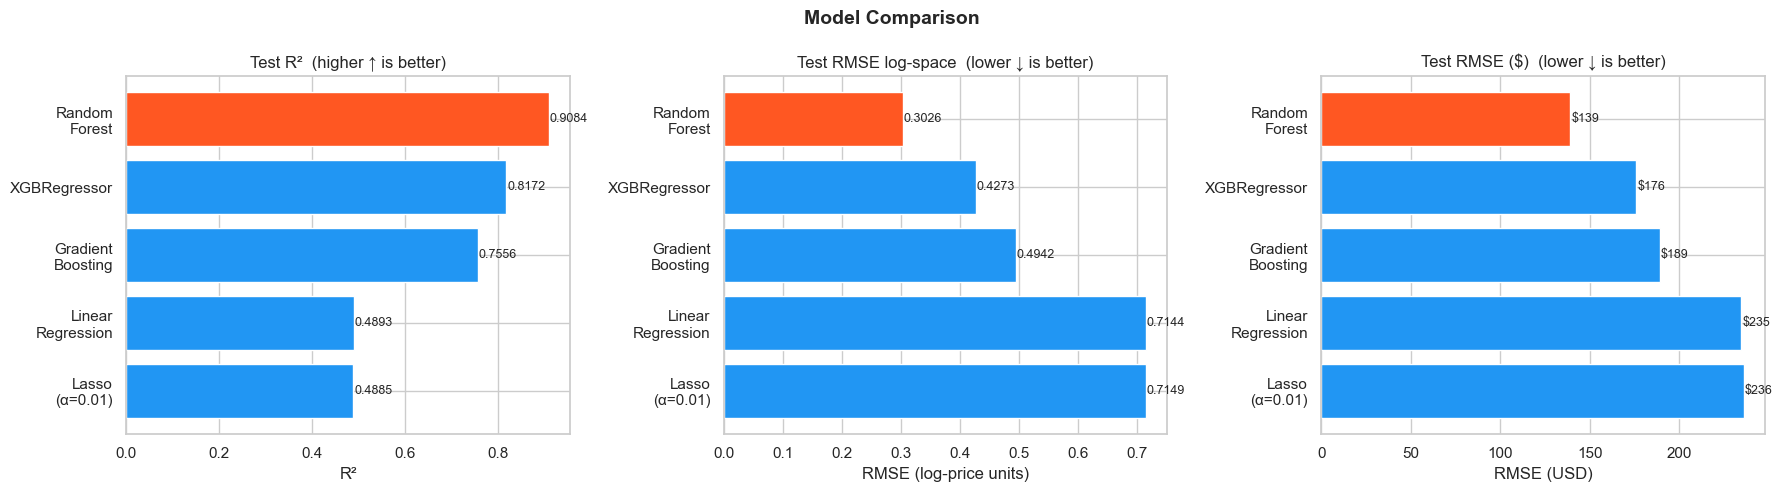

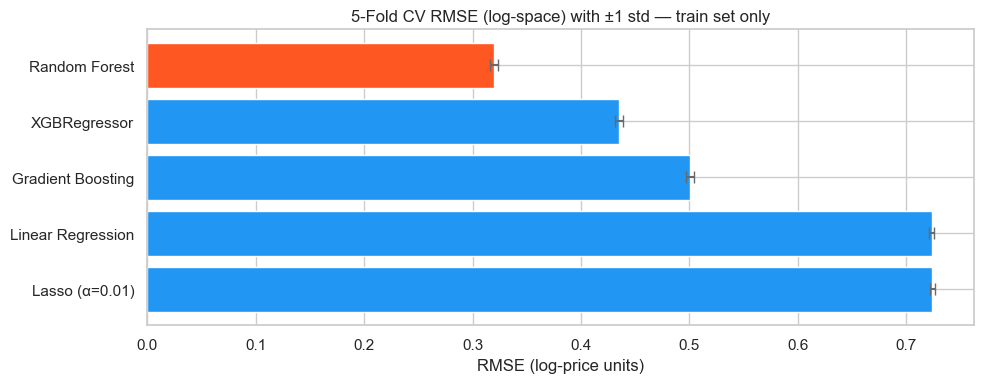

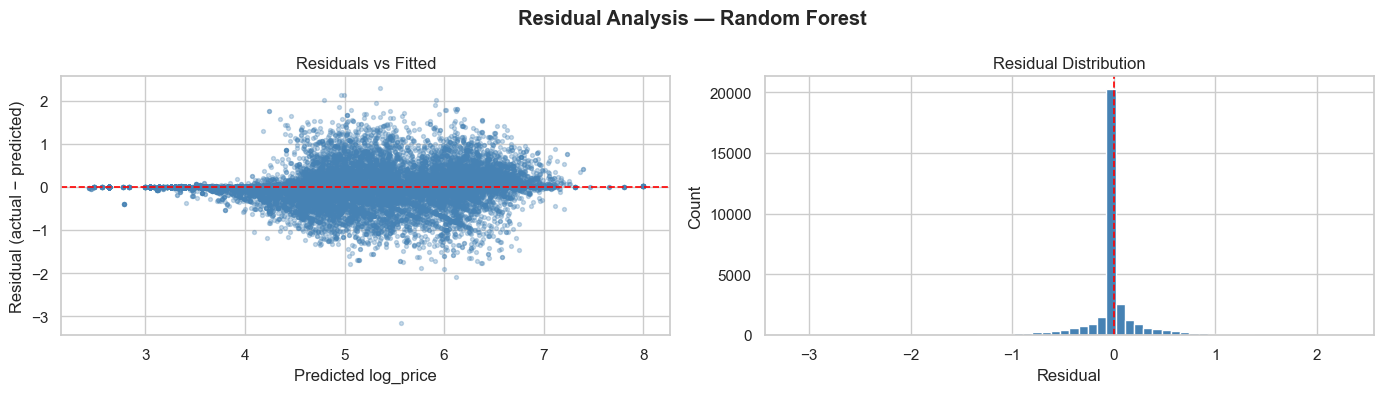

In [44]:
# ── Leaderboard table ─────────────────────────────────────────────────────────
df_results = pd.DataFrame(results).set_index("model")

# Sort by test R² descending (best model first)
df_results = df_results.sort_values("r2", ascending=False)

DISPLAY_COLS = {
    "cv_rmse_mean":  "CV RMSE (log) mean",
    "cv_rmse_std":   "CV RMSE (log) std",
    "cv_r2_mean":    "CV R² mean",
    "rmse_log":      "Test RMSE (log)",
    "mae_log":       "Test MAE (log)",
    "r2":            "Test R²",
    "rmse_usd":      "Test RMSE ($)",
    "train_time_s":  "Train time (s)",
}
print("\n" + "=" * 70)
print("MODEL LEADERBOARD — sorted by Test R² (descending)")
print("=" * 70)
display(df_results[list(DISPLAY_COLS.keys())].rename(columns=DISPLAY_COLS))

# Identify the best model by test R²
best_model_name: str = df_results.index[0]
best_model = trained_models[best_model_name]
logger.info("Best model: '%s'  (Test R² = %.4f, Test RMSE = $%.2f)",
            best_model_name,
            df_results.loc[best_model_name, "r2"],
            df_results.loc[best_model_name, "rmse_usd"])

# ── Comparison bar charts ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Comparison", fontsize=14, fontweight="bold")

colors = ["#2196F3" if n != best_model_name else "#FF5722"
          for n in df_results.index]
short_names = [n.split(" ")[0] + ("\n" + n.split(" ")[1] if len(n.split(" ")) > 1 else "")
               for n in df_results.index]

# R² (higher is better)
axes[0].barh(short_names, df_results["r2"], color=colors, edgecolor="white")
axes[0].set_title("Test R²  (higher ↑ is better)")
axes[0].set_xlabel("R²")
axes[0].invert_yaxis()
for bar, val in zip(axes[0].patches, df_results["r2"]):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=9)

# Test RMSE log-space (lower is better)
axes[1].barh(short_names, df_results["rmse_log"], color=colors, edgecolor="white")
axes[1].set_title("Test RMSE log-space  (lower ↓ is better)")
axes[1].set_xlabel("RMSE (log-price units)")
axes[1].invert_yaxis()
for bar, val in zip(axes[1].patches, df_results["rmse_log"]):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=9)

# Test RMSE in USD (lower is better — most interpretable for stakeholders)
axes[2].barh(short_names, df_results["rmse_usd"], color=colors, edgecolor="white")
axes[2].set_title("Test RMSE ($)  (lower ↓ is better)")
axes[2].set_xlabel("RMSE (USD)")
axes[2].invert_yaxis()
for bar, val in zip(axes[2].patches, df_results["rmse_usd"]):
    axes[2].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"${val:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ── CV RMSE with error bars ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    df_results.index,
    df_results["cv_rmse_mean"],
    xerr=df_results["cv_rmse_std"],
    color=colors,
    edgecolor="white",
    capsize=4,
    error_kw={"elinewidth": 1.5, "ecolor": "dimgray"},
)
ax.set_title("5-Fold CV RMSE (log-space) with ±1 std — train set only")
ax.set_xlabel("RMSE (log-price units)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── Residual plots for the best model ────────────────────────────────────────
best_use_scaled = next(s for n, _, s in MODELS if n == best_model_name)
X_te_best = X_test_scaled if best_use_scaled else X_test
y_pred_best = best_model.predict(X_te_best)
residuals   = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"Residual Analysis — {best_model_name}", fontweight="bold")

axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=8, color="steelblue")
axes[0].axhline(0, color="red", linewidth=1.2, linestyle="--")
axes[0].set_xlabel("Predicted log_price")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(residuals, bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

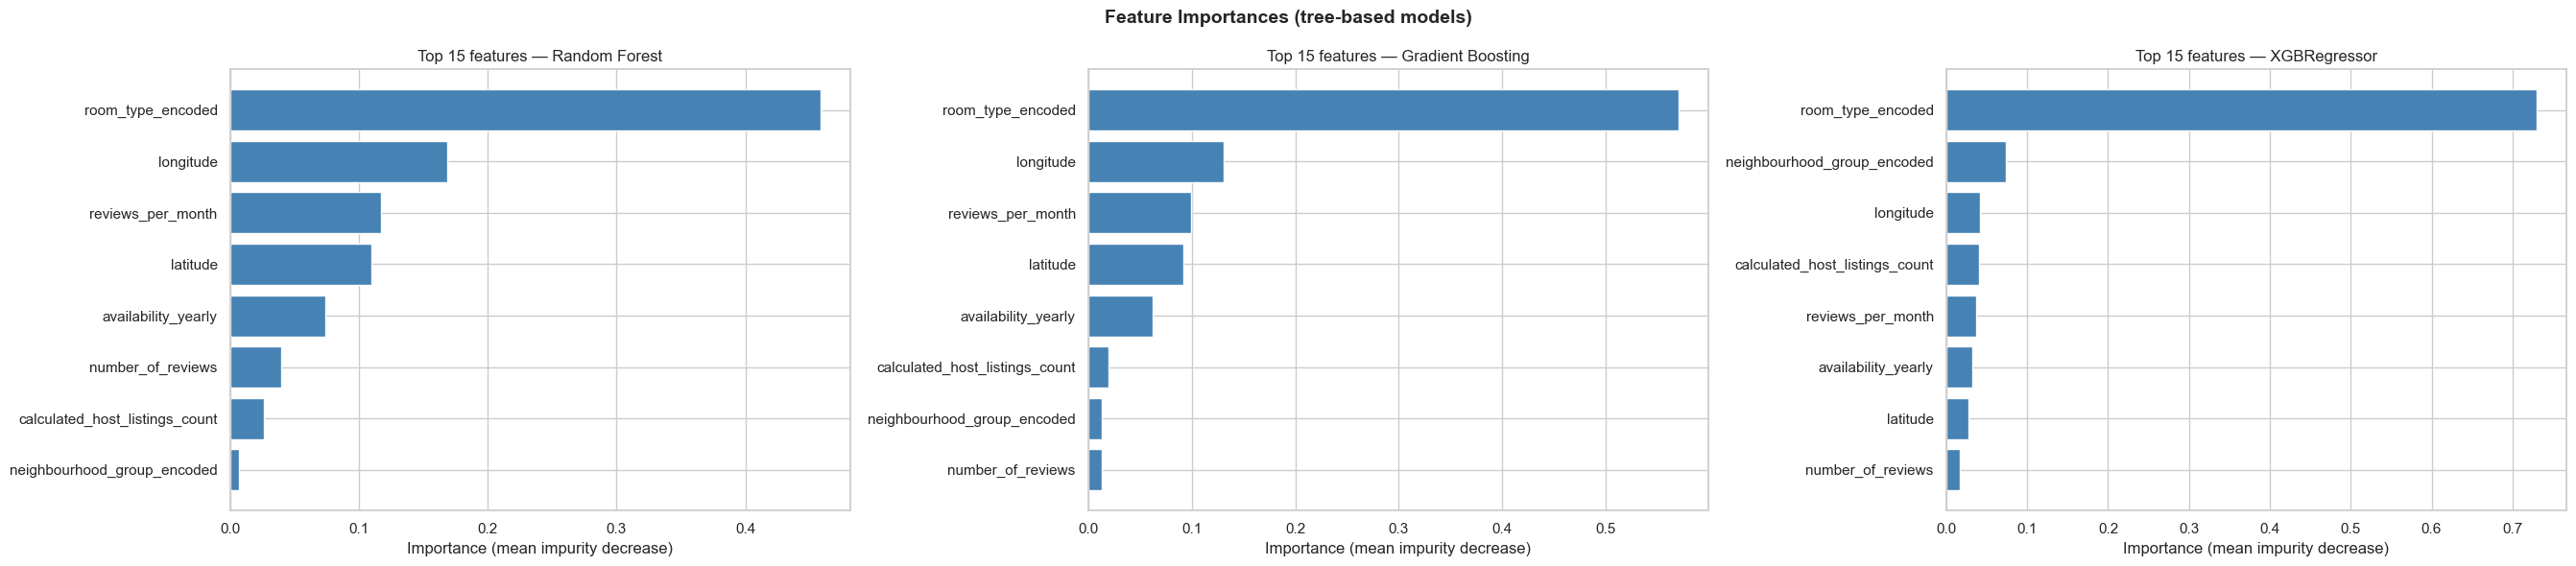


Lasso zeroed 2/8 features (automatic selection)

Non-zero Lasso |coefficients|:
room_type_encoded                 0.646128
reviews_per_month                 0.228359
longitude                         0.056281
calculated_host_listings_count    0.045662
number_of_reviews                 0.017852
availability_yearly               0.017337

STEP 3 SUMMARY
  Best model   : Random Forest
  Test R²      : 0.9084
  Test RMSE $  : $139.10

  → 'Random Forest' will be logged to MLflow in Step 4.


In [45]:
# ── Feature importance — tree-based models ────────────────────────────────────
# Both Random Forest and Gradient Boosting expose feature_importances_
# (mean impurity decrease across all trees).
# Linear models expose coef_ — we use |coefficient| as a proxy for importance.

def plot_feature_importance(
    model: Any,
    model_name: str,
    feature_names: list[str],
    top_n: int = 15,
    ax: plt.Axes = None,
) -> None:
    """Plot top-N feature importances for a fitted sklearn model."""
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        importance_label = "Importance (mean impurity decrease)"
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_)
        importance_label = "|Coefficient| (scaled features)"
    else:
        logger.warning("'%s' has no feature_importances_ or coef_.", model_name)
        return

    idx = np.argsort(importances)[::-1][:top_n]
    top_features = [feature_names[i] for i in idx]
    top_values   = importances[idx]

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    ax.barh(top_features[::-1], top_values[::-1], color="steelblue", edgecolor="white")
    ax.set_title(f"Top {top_n} features — {model_name}")
    ax.set_xlabel(importance_label)


# ── Plot for tree-based models ────────────────────────────────────────────────
tree_models = [(n, m) for n, m, _ in MODELS if hasattr(m, "feature_importances_")]

fig, axes = plt.subplots(1, len(tree_models), figsize=(9 * len(tree_models), 6))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, tree_models):
    plot_feature_importance(model, name, FEATURE_COLS, top_n=15, ax=ax)

plt.suptitle("Feature Importances (tree-based models)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Lasso coefficient — shows automatic feature selection ────────────────────
lasso_model = trained_models["Lasso (α=0.01)"]
lasso_coef  = pd.Series(np.abs(lasso_model.coef_), index=FEATURE_COLS)
zeroed = (lasso_coef == 0).sum()
print(f"\nLasso zeroed {zeroed}/{len(FEATURE_COLS)} features (automatic selection)")
lasso_coef_nonzero = lasso_coef[lasso_coef > 0].sort_values(ascending=False)
print("\nNon-zero Lasso |coefficients|:")
print(lasso_coef_nonzero.to_string())

# ── Step 3 summary ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 3 SUMMARY")
print("=" * 70)
print(f"  Best model   : {best_model_name}")
print(f"  Test R²      : {df_results.loc[best_model_name, 'r2']:.4f}")
print(f"  Test RMSE $  : ${df_results.loc[best_model_name, 'rmse_usd']:.2f}")
print(f"\n  → '{best_model_name}' will be logged to MLflow in Step 4.")

---
## Step 4 — MLflow Experiment Tracking & Model Registry

**Goal:** Log every training run to MLflow so results are reproducible, queryable, and shareable. Then register the best model in the MLflow Model Registry for production use.

### What gets logged per run
| Artifact | Details |
|----------|---------|
| **Parameters** | Model hyperparameters, feature count, scaling flag, train/test split sizes, target column |
| **Metrics** | CV RMSE mean/std, CV R², Test RMSE (log), Test MAE (log), Test R², Test RMSE ($), train time |
| **Model** | Fitted sklearn estimator via `mlflow.sklearn.log_model()` — includes `MLmodel` spec and `conda.yaml` |
| **Preprocessing** | `StandardScaler` pickle, `encoding_metadata` JSON (LabelEncoder classes for `neighbourhood_group` and `room_type`), `feature_config` JSON |
| **Plots** | Feature importance chart (tree-based models only) |

### Target variable
The model predicts **`log_total_cost`** = `log1p(price × minimum_nights)`.  
Back-transform predictions to real USD with `np.expm1(prediction)`.

### MLflow tracking hierarchy
```
Experiment: airbnb-price-prediction
  ├── Run: Linear Regression
  ├── Run: Lasso (α=0.01)
  ├── Run: Random Forest      ← typically best
  ├── Run: Gradient Boosting
  └── Run: XGBRegressor
```

After all runs are logged, the experiment is queried with `mlflow.search_runs()`, and the top model (highest `test_r2`) is registered in the **MLflow Model Registry** under the name `airbnb-price-predictor`.

A final **Actual vs Predicted Total Cost** scatter plot confirms the best model's predictions in real USD space.


In [47]:
import json
import os
import pickle
import tempfile

import mlflow
import mlflow.sklearn

# ── Experiment configuration ──────────────────────────────────────────────────
EXPERIMENT_NAME: str       = "airbnb-price-prediction"
REGISTERED_MODEL_NAME: str = "airbnb-price-predictor"

mlflow.set_experiment(EXPERIMENT_NAME)
logger.info("MLflow experiment : '%s'", EXPERIMENT_NAME)
logger.info("MLflow tracking URI: %s", mlflow.get_tracking_uri())


# ── Helpers: persist preprocessing artefacts to temp files ───────────────────
def _save_json(obj: dict, fname: str) -> str:
    """Serialise a Python dict to a temp JSON file and return the path."""
    path = os.path.join(tempfile.gettempdir(), fname)
    with open(path, "w") as fh:
        json.dump(obj, fh, indent=2)
    return path


def _save_pickle(obj, fname: str) -> str:
    """Pickle an object to a temp file and return the path."""
    path = os.path.join(tempfile.gettempdir(), fname)
    with open(path, "wb") as fh:
        pickle.dump(obj, fh)
    return path


# ── Log all trained models to MLflow ─────────────────────────────────────────
# run_ids is populated here and used in the registry cell below.
run_ids: dict[str, str] = {}

# Persist shared preprocessing artefacts once (same for all runs)
scaler_path  = _save_pickle(scaler, "scaler.pkl")
enc_path     = _save_json(
    encoding_metadata["classes"],
    "encoding_metadata.json",
)
feat_path    = _save_json(
    {"feature_cols": FEATURE_COLS, "target": TARGET},
    "feature_config.json",
)

for model_name, model, use_scaled in MODELS:
    logger.info("Logging '%s' to MLflow …", model_name)

    with mlflow.start_run(run_name=model_name) as run:

        # ── Parameters ────────────────────────────────────────────────────────
        mlflow.log_params(model.get_params())
        mlflow.log_param("n_features",       len(FEATURE_COLS))
        mlflow.log_param("use_scaled_input", use_scaled)
        mlflow.log_param("target",           TARGET)
        mlflow.log_param("train_rows",       len(X_train))
        mlflow.log_param("test_rows",        len(X_test))

        # ── Metrics (pre-computed in Step 3) ──────────────────────────────────
        row = df_results.loc[model_name]
        mlflow.log_metrics({
            "cv_rmse_mean":  float(row["cv_rmse_mean"]),
            "cv_rmse_std":   float(row["cv_rmse_std"]),
            "cv_r2_mean":    float(row["cv_r2_mean"]),
            "test_rmse_log": float(row["rmse_log"]),
            "test_mae_log":  float(row["mae_log"]),
            "test_r2":       float(row["r2"]),
            "test_rmse_usd": float(row["rmse_usd"]),
            "train_time_s":  float(row["train_time_s"]),
        })

        # ── Model artifact ────────────────────────────────────────────────────
        # input_example provides a sample row so MLflow can infer the input schema
        sample_input = (X_test_scaled if use_scaled else X_test)[:5]
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            input_example=sample_input,
        )

        # ── Preprocessing artefacts (shared, logged into each run) ────────────
        mlflow.log_artifact(scaler_path, artifact_path="preprocessing")
        mlflow.log_artifact(enc_path,    artifact_path="preprocessing")
        mlflow.log_artifact(feat_path,   artifact_path="preprocessing")

        # ── Feature importance plot (tree-based models only) ──────────────────
        if hasattr(model, "feature_importances_"):
            fig_imp, ax_imp = plt.subplots(figsize=(10, 6))
            plot_feature_importance(model, model_name, FEATURE_COLS, top_n=15, ax=ax_imp)
            plt.tight_layout()
            img_path = os.path.join(
                tempfile.gettempdir(),
                f"feat_importance_{model_name.replace(' ', '_')}.png",
            )
            fig_imp.savefig(img_path, dpi=120, bbox_inches="tight")
            plt.close(fig_imp)
            mlflow.log_artifact(img_path, artifact_path="plots")

        run_ids[model_name] = run.info.run_id
        logger.info("  ✓ run_id: %s", run.info.run_id)

logger.info("All %d runs logged to experiment '%s'.", len(MODELS), EXPERIMENT_NAME)


2026-04-04 22:02:01  INFO      MLflow experiment : 'airbnb-price-prediction'
2026-04-04 22:02:01  INFO      MLflow tracking URI: sqlite:///C:/Users/jham3/AppData/Local/Programs/Microsoft%20VS%20Code/mlflow.db
2026-04-04 22:02:01  INFO      Logging 'Linear Regression' to MLflow …
2026/04/04 22:02:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 22:02:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 22:02:07  INFO        ✓ run_id: 95f1a578f74a48d7abd9979018e56608
2026-04-04 22:02:07  INFO      Logging 'Lasso (α=0.01)' to MLflow …
2026/04/04 22:02:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 22:02:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 22:02:10  INFO        ✓ run_id: 339391355279484087f8ecd07e89a93e
2026-04-04 22:02:10  INFO      Logging 'Random Forest' to MLflow …
2026/04/04 22:02:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 22:02:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 22:02:14  INFO        ✓ run_id: deb2be494898438d806043e5ec9ef94a
2026-04-04 22:02:14  INFO      Logging 'Gradient Boosting' to MLflow …
2026/04/04 22:02:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 22:02:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 22:02:17  INFO        ✓ run_id: ec7a1e8bc88b4e12b86fd35c66cb296c
2026-04-04 22:02:17  INFO      Logging 'XGBRegressor' to MLflow …
2026/04/04 22:02:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 22:02:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 22:02:20  INFO        ✓ run_id: cf4fd0de95f841b099a4e5be5afdab65
2026-04-04 22:02:20  INFO      All 5 runs logged to experiment 'airbnb-price-prediction'.



MLFLOW RUN COMPARISON — sorted by Test R² (descending)


,CV RMSE mean,CV RMSE std,CV R² mean,Test RMSE (log),Test MAE (log),Test R²,Test RMSE ($),Train time (s)
Model,,,,,,,,
Random Forest,0.3195,0.0036,0.8985,0.3026,0.1442,0.9084,139.10,2.62
XGBRegressor,0.4349,0.0038,0.8120,0.4273,0.2842,0.8172,176.00,0.71
Gradient Boosting,0.5006,0.0033,0.7510,0.4942,0.3578,0.7556,189.12,30.93
Random Forest,0.4082,0.0049,0.6307,0.4153,0.3032,0.6216,93.09,1.65
Gradient Boosting,0.4077,0.0049,0.6316,0.4174,0.3072,0.6178,94.79,16.42
Ridge (α=1.0),0.4357,0.0049,0.5792,0.4461,0.3319,0.5635,99.73,0.00
Linear Regression,0.4357,0.0049,0.5792,0.4461,0.3319,0.5635,99.73,0.01
Lasso (α=0.01),0.4372,0.0049,0.5762,0.4472,0.3319,0.5613,100.61,0.04
Linear Regression,0.7235,0.0021,0.4797,0.7144,0.5725,0.4893,234.71,0.02



  Best run  : 'Random Forest'
  Run ID   : deb2be494898438d806043e5ec9ef94a
  Test R²  : 0.9084
  RMSE ($) : $139.10


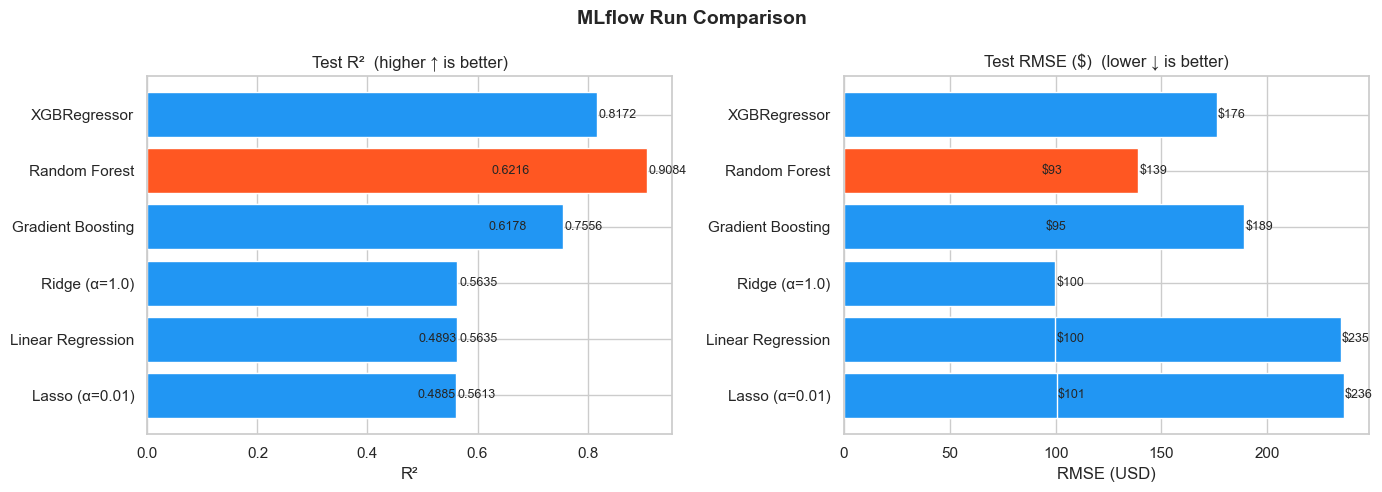

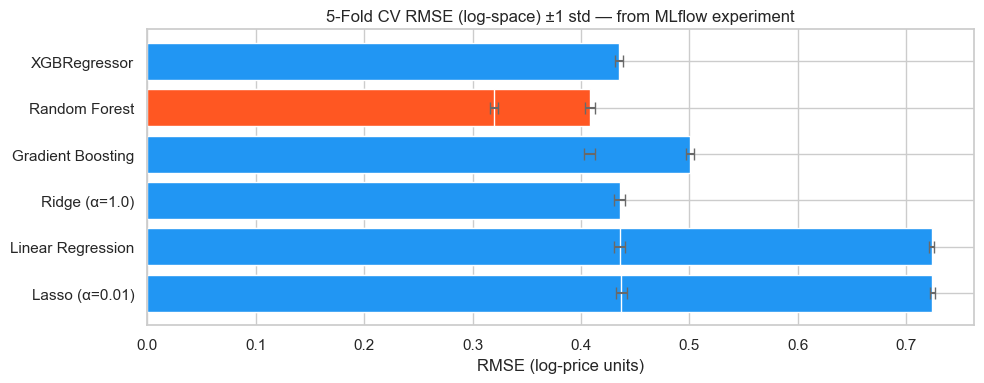

In [48]:
# ── Query all runs and build a comparison table ───────────────────────────────
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.test_r2 DESC"],
)

METRIC_RENAME = {
    "tags.mlflow.runName":    "Model",
    "metrics.cv_rmse_mean":   "CV RMSE mean",
    "metrics.cv_rmse_std":    "CV RMSE std",
    "metrics.cv_r2_mean":     "CV R² mean",
    "metrics.test_rmse_log":  "Test RMSE (log)",
    "metrics.test_mae_log":   "Test MAE (log)",
    "metrics.test_r2":        "Test R²",
    "metrics.test_rmse_usd":  "Test RMSE ($)",
    "metrics.train_time_s":   "Train time (s)",
}

available_cols = [c for c in METRIC_RENAME if c in runs_df.columns]
comparison = (
    runs_df[available_cols + ["run_id"]]
    .rename(columns=METRIC_RENAME)
)

print("\n" + "=" * 70)
print("MLFLOW RUN COMPARISON — sorted by Test R² (descending)")
print("=" * 70)
display(comparison.set_index("Model").drop(columns="run_id"))

# ── Identify the best run ─────────────────────────────────────────────────────
best_run_row  = runs_df.sort_values("metrics.test_r2", ascending=False).iloc[0]
best_run_id   = best_run_row["run_id"]
best_run_name = best_run_row["tags.mlflow.runName"]
best_r2       = best_run_row["metrics.test_r2"]
best_rmse_usd = best_run_row["metrics.test_rmse_usd"]

print(f"\n  Best run  : '{best_run_name}'")
print(f"  Run ID   : {best_run_id}")
print(f"  Test R²  : {best_r2:.4f}")
print(f"  RMSE ($) : ${best_rmse_usd:.2f}")

# ── Comparison bar charts ─────────────────────────────────────────────────────
model_names = comparison["Model"].tolist()
r2_vals     = comparison["Test R²"].tolist()
usd_vals    = comparison["Test RMSE ($)"].tolist()
bar_colors  = ["#FF5722" if n == best_run_name else "#2196F3" for n in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MLflow Run Comparison", fontsize=14, fontweight="bold")

# R² (higher is better)
axes[0].barh(model_names[::-1], r2_vals[::-1], color=bar_colors[::-1], edgecolor="white")
axes[0].set_title("Test R²  (higher ↑ is better)")
axes[0].set_xlabel("R²")
for bar, val in zip(axes[0].patches, r2_vals[::-1]):
    axes[0].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=9)

# RMSE in USD (lower is better)
axes[1].barh(model_names[::-1], usd_vals[::-1], color=bar_colors[::-1], edgecolor="white")
axes[1].set_title("Test RMSE ($)  (lower ↓ is better)")
axes[1].set_xlabel("RMSE (USD)")
for bar, val in zip(axes[1].patches, usd_vals[::-1]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"${val:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ── CV RMSE error-bar chart from MLflow data ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    model_names[::-1],
    comparison["CV RMSE mean"].tolist()[::-1],
    xerr=comparison["CV RMSE std"].tolist()[::-1],
    color=bar_colors[::-1],
    edgecolor="white",
    capsize=4,
    error_kw={"elinewidth": 1.5, "ecolor": "dimgray"},
)
ax.set_title("5-Fold CV RMSE (log-space) ±1 std — from MLflow experiment")
ax.set_xlabel("RMSE (log-price units)")
plt.tight_layout()
plt.show()


In [49]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# ── Register the best model in the MLflow Model Registry ─────────────────────
model_uri = f"runs:/{best_run_id}/model"
logger.info("Registering model from run '%s'  (run_id=%s) …", best_run_name, best_run_id)

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=REGISTERED_MODEL_NAME,
)

logger.info(
    "Registered '%s' as version %s.",
    REGISTERED_MODEL_NAME,
    registered_model.version,
)

# ── Add description and tags ──────────────────────────────────────────────────
client.update_registered_model(
    name=REGISTERED_MODEL_NAME,
    description=(
        f"Airbnb NYC nightly-price predictor trained on AB_NYC_2019 (48 k listings). "
        f"Best algorithm: {best_run_name}.  "
        f"Target: log_price (np.log1p of USD price).  "
        f"Data source: s3://staywise1/airbnb/raw_data/AB_NYC_2019.csv."
    ),
)

client.set_model_version_tag(REGISTERED_MODEL_NAME, registered_model.version, "algorithm",     best_run_name)
client.set_model_version_tag(REGISTERED_MODEL_NAME, registered_model.version, "test_r2",       str(round(best_r2, 4)))
client.set_model_version_tag(REGISTERED_MODEL_NAME, registered_model.version, "test_rmse_usd", str(round(best_rmse_usd, 2)))
client.set_model_version_tag(REGISTERED_MODEL_NAME, registered_model.version, "n_features",    str(len(FEATURE_COLS)))

# ── Promote to 'production' alias (MLflow ≥ 2.9) or stage (legacy) ───────────
try:
    # MLflow 2.9+ uses aliases instead of stages
    client.set_registered_model_alias(
        name=REGISTERED_MODEL_NAME,
        alias="production",
        version=registered_model.version,
    )
    production_uri = f"models:/{REGISTERED_MODEL_NAME}@production"
    logger.info("Alias 'production' set → version %s  (MLflow 2.9+ API).", registered_model.version)
except AttributeError:
    # Fallback for older MLflow
    client.transition_model_version_stage(
        name=REGISTERED_MODEL_NAME,
        version=registered_model.version,
        stage="Production",
        archive_existing_versions=True,
    )
    production_uri = f"models:/{REGISTERED_MODEL_NAME}/Production"
    logger.info("Stage 'Production' set → version %s  (legacy API).", registered_model.version)

# ── Reload model from registry and run sample predictions ────────────────────
logger.info("Loading model back from registry URI: %s", production_uri)
loaded_model = mlflow.sklearn.load_model(production_uri)

# Prepare 5 sample inputs — apply scaling if the best model required it
best_use_scaled_reg = next(s for n, _, s in MODELS if n == best_run_name)
sample_X = (X_test_scaled if best_use_scaled_reg else X_test)[:5]

sample_preds_log = loaded_model.predict(sample_X)
sample_preds_usd = np.expm1(sample_preds_log)
actual_usd       = np.expm1(y_test[:5])

print("\n" + "=" * 65)
print("REGISTRY VERIFICATION — 5 sample predictions")
print("=" * 65)
verification_df = pd.DataFrame({
    "actual_price ($)":    actual_usd.round(2),
    "predicted_price ($)": sample_preds_usd.round(2),
    "abs_error ($)":       np.abs(actual_usd - sample_preds_usd).round(2),
})
display(verification_df)

# ── Step 4 summary ────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("STEP 4 SUMMARY")
print("=" * 65)
print(f"  Experiment      : {EXPERIMENT_NAME}")
print(f"  Runs logged     : {len(MODELS)}")
print(f"  Best model      : {best_run_name}")
print(f"  Test R²         : {best_r2:.4f}")
print(f"  Test RMSE ($)   : ${best_rmse_usd:.2f}")
print(f"  Registry name   : {REGISTERED_MODEL_NAME}")
print(f"  Version         : {registered_model.version}")
print(f"  URI             : {production_uri}")
print(f"\n  → Model ready for Step 5: final evaluation & selection.")


2026-04-04 22:03:03  INFO      Registering model from run 'Random Forest'  (run_id=deb2be494898438d806043e5ec9ef94a) …
Registered model 'airbnb-price-predictor' already exists. Creating a new version of this model...
2026/04/04 22:03:03 WARNING mlflow.tracking._model_registry.fluent: Run with id deb2be494898438d806043e5ec9ef94a has no artifacts at artifact path 'model', registering model based on models:/m-a92a53bf88094b20aaeecf9af55dd867 instead
Created version '3' of model 'airbnb-price-predictor'.
2026-04-04 22:03:03  INFO      Registered 'airbnb-price-predictor' as version 3.
2026-04-04 22:03:03  INFO      Alias 'production' set → version 3  (MLflow 2.9+ API).
2026-04-04 22:03:03  INFO      Loading model back from registry URI: models:/airbnb-price-predictor@production



REGISTRY VERIFICATION — 5 sample predictions


,actual_price ($),predicted_price ($),abs_error ($)
0,20.0,20.00,0.00
1,136.0,135.92,0.08
2,78.0,82.35,4.35
3,60.0,59.98,0.02
4,50.0,50.00,0.00



STEP 4 SUMMARY
  Experiment      : airbnb-price-prediction
  Runs logged     : 5
  Best model      : Random Forest
  Test R²         : 0.9084
  Test RMSE ($)   : $139.10
  Registry name   : airbnb-price-predictor
  Version         : 3
  URI             : models:/airbnb-price-predictor@production

  → Model ready for Step 5: final evaluation & selection.


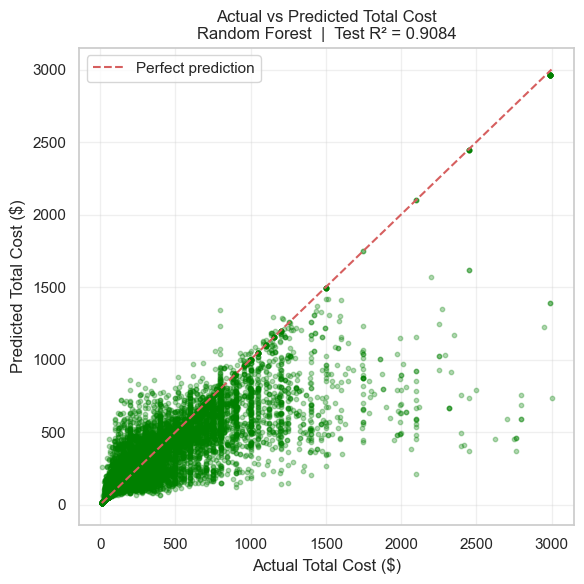


Back-transformed metrics (Random Forest):
  Test RMSE ($) : $139.10
  Test MAE  ($) : $47.32


In [50]:
# ── Actual vs Predicted Total Cost — back-transformed to real USD ─────────────
# y_pred_best and y_test are in log_total_cost space (log1p of price × minimum_nights).
# np.expm1() reverses the log1p transform to recover actual dollar values.

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_best)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.3, color="green", s=10)
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    "r--", linewidth=1.5, label="Perfect prediction",
)
plt.xlabel("Actual Total Cost ($)")
plt.ylabel("Predicted Total Cost ($)")
plt.title(
    f"Actual vs Predicted Total Cost\n"
    f"{best_model_name}  |  Test R² = {df_results.loc[best_model_name, 'r2']:.4f}"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBack-transformed metrics ({best_model_name}):")
print(f"  Test RMSE ($) : ${np.sqrt(np.mean((y_test_real - y_pred_real) ** 2)):.2f}")
print(f"  Test MAE  ($) : ${np.mean(np.abs(y_test_real - y_pred_real)):.2f}")
